This file outlines steps 7-12 of the data analysis pipeline for the Ubuntu Dialogue Corpus dataset, sourced from Kaggle. In our last file, we exported steps 1-6 as a pkl file that is used as the new dataframe for steps 7-12. 

Before beginning step 7, I am checking if there are any missing values that do not show up as NaN, despite being empty, because step 6 indicated they may be present. I will incorporate this method of checking into future iterations of step 5: handle missing values. 

In [1]:
#imports
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_colwidth', None)  # Show full content of columns

In [3]:
df = pd.read_pickle('ubuntu_dialogue_step6.pkl')
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")

df['days_until_release'] = pd.to_numeric(df['days_until_release'], downcast='unsigned')
print(df.dtypes)

Loaded 8,589,731 rows, 13 columns
date                  datetime64[us]
from                        category
to                          category
text                             str
conversation_id               uint32
turn_count                     int16
is_op                           bool
response_gap_mins            float64
user_message_count             int32
text_length                    int16
word_count                     int16
days_since_release           float64
days_until_release             uint8
dtype: object


In [4]:
(df['word_count'] == 0).sum() #check

np.int64(547)

In [5]:
df[(df['word_count'] == 0)].head(5)[['date','from','to','text_length','word_count','text']]

,date,from,to,text_length,word_count,text
2917,2012-10-05 10:24:00,EdMarx,wes332,1,0,
7938,2012-06-17 16:55:00,georg87,__ALL__,1,0,
38124,2012-03-08 14:58:00,BlueWolf,nibbler,1,0,
54688,2011-04-18 22:23:00,fizyplan1ton,__ALL__,1,0,
64761,2011-02-03 19:05:00,Guest54266,__ALL__,1,0,


In [6]:
#remove these
df = df[df['word_count'] != 0].reset_index(drop=True)

In [7]:
(df['text_length'] == 0).sum() #check

np.int64(0)

In [8]:
print("blank 'from':", (df['from'] == '').sum())
print("blank 'to':", (df['to'] == '').sum())

blank 'from': 0
blank 'to': 0


In [9]:
df['from'].astype(str).str.strip().eq('').sum()

np.int64(0)

In [10]:
df['to'].astype(str).str.strip().eq('').sum()

np.int64(0)

In [11]:
#Check if there's any conversations with more than 2 users
participant_counts = df.groupby('conversation_id')['from'].nunique()
multi_party_ids = participant_counts[participant_counts > 2].index

print("conversations with 3+ users:", len(multi_party_ids))
print("as % of all conversations:", round(len(multi_party_ids) / df['conversation_id'].nunique() * 100, 2))
print("rows affected:", df['conversation_id'].isin(multi_party_ids).sum())

conversations with 3+ users: 0
as % of all conversations: 0.0
rows affected: 0


In [12]:
#Create a new variable that measures response times between users only, not within
prev_from = df.groupby('conversation_id')['from'].shift()
speaker_changed = df['from'] != prev_from

df['response_gap_mins_between_speakers'] = df['response_gap_mins'].where(speaker_changed)

print("dtype:", df['response_gap_mins_between_speakers'].dtype)
print("NaN in response_gap_mins:", df['response_gap_mins'].isna().sum())
print("NaN in response_gap_mins_between_speakers:", df['response_gap_mins_between_speakers'].isna().sum())

dtype: float64
NaN in response_gap_mins: 1008220
NaN in response_gap_mins_between_speakers: 4754423


---
Evidently, there are 547 non-NaN yet empty text strings, likely filled with "tabs" or other whitespace characters. We have removed these from the dataset. 

Other thoughts: We were seeing many zeros in response_gap_mins... currently, it only checks the immediate prior message. But in reality, there should also be a subset where it is the response_gap_mins between users only. So it only looks at messages where turn count +=1 and is_op != is_op. otherwise ignores. This is important because a user may send multiple messages in quick succession, underrepresenting the time taken to actually respond to the other user, as the user is just replying to himself/herself. 

---
Step 7: Deep Exploration 📊 
- groupby() summaries
- value_counts() distributions
- pivot_table() cross-tabs
- Check for outliers
- Identify patterns

Grouping by: Year, Month, User, Conversation_ID, days_until_release / since_release buckets, is_op, text_length and word_count buckets, user_message_counts, response_gap_mins buckets

In [13]:
#Group By
# Year / Month
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# release-distance buckets — weekly bins
release_bins = [-1, 7, 14, 21, 28, 42, 56, float('inf')]
release_labels = ['0-1wk', '1-2wk', '2-3wk', '3-4wk', '4-6wk', '6-8wk', '8wk+']
df['days_since_release_bucket'] = pd.cut(df['days_since_release'], bins=release_bins, labels=release_labels)
df['days_until_release_bucket'] = pd.cut(df['days_until_release'], bins=release_bins, labels=release_labels)

# message length buckets
df['text_length_bucket'] = pd.cut(df['text_length'], bins=[0, 20, 50, 100, 200, float('inf')],
                                    labels=['very_short', 'short', 'medium', 'long', 'very_long'])
df['word_count_bucket'] = pd.cut(df['word_count'], bins=[0, 5, 10, 20, 40, float('inf')],
                                   labels=['very_short', 'short', 'medium', 'long', 'very_long'])

# user-tiers based on messages sent per user per month
monthly_counts = (
    df.groupby(['from', 'year', 'month'], observed=True)
    .size()
    .rename('user_messages_this_month')
    .reset_index()
)
df = df.merge(monthly_counts, on=['from', 'year', 'month'], how='left')

# response latency buckets
df['response_gap_bucket'] = pd.cut(df['response_gap_mins_between_speakers'], bins=[-1, 5, 30, 120, 1440, float('inf')],
                                     labels=['<5min', '5-30min', '30min-2hr', '2hr-1day', '1day+'])

In [14]:
df['user_messages_this_month'].describe() #check

count    8.589184e+06
mean     2.526164e+02
std      4.902072e+02
min      1.000000e+00
25%      1.600000e+01
50%      5.200000e+01
75%      2.220000e+02
max      4.075000e+03
Name: user_messages_this_month, dtype: float64

In [15]:
#Value Count Distributions, Group By
df['user_tier'] = pd.cut(df['user_messages_this_month'], #User Tier Categorical Proportions
                          bins=[0, 10, 50, 150, 500, float('inf')],
                          labels=['occasional', 'regular', 'active', 'frequent', 'power_user'])
print(df['user_tier'].value_counts(normalize=True))

user_tier
regular       0.333215
active        0.200701
occasional    0.161327
frequent      0.156353
power_user    0.148404
Name: proportion, dtype: float64


---
User_tiers -- Earlier operational definition of this variable utilized mere cumulative message count per user. The engineered user tiers feature should instead examine messages sent per month or similar, not simply per conversation or cumulative. Legacy users are persistent, but other users may have been active in earlier years (high cumulative count), but hardly post anymore, and that should be reflected. 

---

In [16]:
df['days_since_release_bucket'].value_counts(dropna=False).sort_index() #days_since_release

days_since_release_bucket
0-1wk     574948
1-2wk     413496
2-3wk     365994
3-4wk     328585
4-6wk     657942
6-8wk     626717
8wk+     5582979
NaN        38523
Name: count, dtype: int64

In [17]:
df['days_until_release_bucket'].value_counts().sort_index() #days_until_release

days_until_release_bucket
0-1wk     366478
1-2wk     311169
2-3wk     319214
3-4wk     310929
4-6wk     609220
6-8wk     614458
8wk+     6057716
Name: count, dtype: int64

In [18]:
df.groupby('days_since_release_bucket', observed=True, dropna=False)['is_op'].mean() #portion of messages sent by OP by time since last release

days_since_release_bucket
0-1wk    0.578758
1-2wk    0.571188
2-3wk    0.572780
3-4wk    0.573325
4-6wk    0.571780
6-8wk    0.571103
8wk+     0.571773
NaN      0.587623
Name: is_op, dtype: float64

In [19]:
df.groupby('days_until_release_bucket', observed=True)['is_op'].mean() #portion of messages sent by OP by time until next release

days_until_release_bucket
0-1wk    0.577303
1-2wk    0.571667
2-3wk    0.569743
3-4wk    0.573552
4-6wk    0.570940
6-8wk    0.571666
8wk+     0.572355
Name: is_op, dtype: float64

In [20]:
df.groupby('days_since_release_bucket', observed=True, dropna=False)[['text_length', 'word_count']].mean() #text length/word count by days since release

,text_length,word_count
days_since_release_bucket,,
0-1wk,55.150240,10.157489
1-2wk,54.577137,10.063398
2-3wk,54.561886,10.067553
3-4wk,54.306374,10.014292
4-6wk,54.221290,10.006248
6-8wk,53.820527,9.942843
8wk+,53.743373,9.928472
NaN,47.082912,8.678685


In [21]:
df.groupby('days_until_release_bucket', observed=True)[['text_length', 'word_count']].mean() #text length/word count by days until release

,text_length,word_count
days_until_release_bucket,,
0-1wk,52.552134,9.714190
1-2wk,52.820123,9.766567
2-3wk,53.442766,9.865178
3-4wk,53.430220,9.874357
4-6wk,54.091995,9.991689
6-8wk,54.169063,10.006155
8wk+,54.104505,9.987619


In [22]:
df.groupby('days_since_release_bucket', observed=True, dropna=False)['response_gap_mins_between_speakers'].median() #response gap in minutes by days since release

days_since_release_bucket
0-1wk    1.0
1-2wk    1.0
2-3wk    1.0
3-4wk    1.0
4-6wk    1.0
6-8wk    1.0
8wk+     1.0
NaN      1.0
Name: response_gap_mins_between_speakers, dtype: float64

In [23]:
df.groupby('days_until_release_bucket', observed=True)['response_gap_mins_between_speakers'].median() #response gap in minutes by days until release

days_until_release_bucket
0-1wk    1.0
1-2wk    1.0
2-3wk    1.0
3-4wk    1.0
4-6wk    1.0
6-8wk    1.0
8wk+     1.0
Name: response_gap_mins_between_speakers, dtype: float64

In [24]:
df.groupby('user_tier', observed=True)['response_gap_mins_between_speakers'].median()

user_tier
occasional    1.0
regular       1.0
active        1.0
frequent      1.0
power_user    1.0
Name: response_gap_mins_between_speakers, dtype: float64

In [25]:
df.groupby('user_tier', observed=True)['is_op'].mean()

user_tier
occasional    0.767553
regular       0.702183
active        0.558529
frequent      0.391031
power_user    0.278272
Name: is_op, dtype: float64

In [26]:
#Pivot Table
pd.pivot_table(df, index='days_since_release_bucket', columns='user_tier', values='conversation_id', aggfunc='count', observed=True)

user_tier,occasional,regular,active,frequent,power_user
days_since_release_bucket,,,,,
0-1wk,103860,199511,119036,83112,69429
1-2wk,67107,137965,83767,64737,59920
2-3wk,58988,123672,75674,55176,52484
3-4wk,52750,112100,67932,48768,47035
4-6wk,107724,225828,132573,100751,91066
6-8wk,98701,209855,122429,99625,96107
8wk+,893216,1842532,1113173,881677,852381


In [27]:
#Examine the new numeric columns with describe, determine patterns, outliers, and need for distribution transformations
df.drop(columns=['date', 'conversation_id']).describe().apply(lambda x: x.apply('{:.2f}'.format)) #describe with hundredths precision

,turn_count,response_gap_mins,user_message_count,text_length,word_count,days_since_release,days_until_release,response_gap_mins_between_speakers,year,month,user_messages_this_month
count,8589184.00,7580964.00,8589184.00,8589184.00,8589184.00,8550661.00,8589184.00,3834761.00,8589184.00,8589184.00,8589184.00
mean,9.72,2624.51,2500.14,53.95,9.96,87.41,95.63,2134.27,2008.04,6.52,252.62
std,19.53,43336.26,8480.26,49.58,9.10,55.97,55.96,38641.99,2.14,3.40,490.21
min,0.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,2004.00,1.00,1.00
25%,2.00,0.00,16.00,21.00,4.00,38.00,48.00,0.00,2006.00,4.00,16.00
50%,5.00,1.00,86.00,41.00,8.00,85.00,95.00,1.00,2008.00,6.00,52.00
75%,10.00,1.00,676.00,72.00,13.00,134.00,143.00,1.00,2010.00,10.00,222.00
max,759.00,3824279.00,96702.00,471.00,173.00,231.00,231.00,3824279.00,2012.00,12.00,4075.00


In [28]:
#Introduce key identifier per message and place conversation_id second
df['message_id'] = pd.array(range(1, len(df) + 1), dtype='uint32')

cols = ['message_id', 'conversation_id', 'date'] + [c for c in df.columns if c not in ['message_id', 'conversation_id', 'date']]
df = df[cols]

In [29]:
df.sample(3)

,message_id,conversation_id,date,from,to,text,turn_count,is_op,response_gap_mins,user_message_count,...,response_gap_mins_between_speakers,year,month,days_since_release_bucket,days_until_release_bucket,text_length_bucket,word_count_bucket,user_messages_this_month,response_gap_bucket,user_tier
1994991,1994992,558833,2011-12-08 13:32:00,crescendo,Vermind,"hrm, that didn't correctly resolve my issue either.",4,True,0.0,110,...,NaN,2011,12,6-8wk,8wk+,medium,short,6,NaN,occasional
2693615,2693616,635602,2010-10-29 08:14:00,macool,__ALL__,I got a question about Apache..,0,True,NaN,7,...,NaN,2010,10,2-3wk,8wk+,short,short,8,NaN,occasional
5558423,5558424,893127,2011-12-30 22:11:00,munzir,ActionParsnip,now I don't have it connected and still I want to add it,11,True,1.0,196,...,1.0,2011,12,8wk+,8wk+,medium,medium,8,<5min,occasional


---
EDA Notes: 

Data Health Check:
- check known NaN (present only in days_since_release and response_gap_mins) as a percentage of total rows. 
- identify any zero-variance/constant columns, which present issues downstream

Univariate:
1. Continuous, Numeric Variables: First we do single variable distributions and see about outliers, and whether transformations are necessary. 
- Calculate skewness and kurtosis, identify outliers via Z-score or IQR. 
- Visuals: box/whisker, histogram... Q-Q, residuals plot, density plot (consider natural floor and ceiling in data, use Subject Matter Expertise)
2. Binary, Categorical:
- Class imbalances, concentration spikes
- pie chart, bar chart, or similar.


Multivariate: Relational
- correlation matrix, identify variables that correlate +/-0.5
- Visuals: correlation heatmap, scatter matrix, line charts (time, distance, dosage, temperature, position)
- We see if any variables pose risks for multicollinearity (high correlation + VIF), as well as potential need for interaction terms or PCA/similar. 
- note: always prevent dummy variable bias by leaving out one category AKA the base case (often largest group size, or control/zero-state)

In [30]:
#Health Check
missing_pct = (df.isna().sum() / len(df) * 100).round(2)
print(missing_pct[missing_pct > 0])

constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print("Constant columns:", constant_cols)

response_gap_mins                     11.74
days_since_release                     0.45
response_gap_mins_between_speakers    55.35
days_since_release_bucket              0.45
response_gap_bucket                   55.35
dtype: float64
Constant columns: []


In [31]:
#Univariate:
continuous_cols = ['turn_count', 'response_gap_mins_between_speakers', 'user_message_count',
                    'text_length', 'word_count', 'days_since_release', 'days_until_release']

In [32]:
# skew + kurtosis
skew_kurt = pd.DataFrame({
    'skew': df[continuous_cols].skew(),
    'kurtosis': df[continuous_cols].kurt()
})
print(skew_kurt) 
#kurtosis of +/- 7 and skewness of +/- 2 considered problematic as violating laws of normality

                                         skew     kurtosis
turn_count                           9.082380   156.548237
response_gap_mins_between_speakers  32.989542  1483.331031
user_message_count                   5.979257    43.399858
text_length                          2.326545     8.863833
word_count                           2.324110     8.849882
days_since_release                   0.179466    -1.020490
days_until_release                   0.056977    -1.072514


In [33]:
# outliers: IQR and Z-score side by side
def iqr_outlier_count(series):
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lower) | (s > upper)).sum())

def zscore_outlier_count(series, threshold=3):
    s = series.dropna()
    z = (s - s.mean()) / s.std()
    return int((z.abs() > threshold).sum())

outlier_summary = pd.DataFrame({
    'iqr_outliers': {c: iqr_outlier_count(df[c]) for c in continuous_cols},
    'zscore_outliers': {c: zscore_outlier_count(df[c]) for c in continuous_cols},
})

outlier_summary['iqr_pct'] = (outlier_summary['iqr_outliers'] / len(df) * 100).round(2)
outlier_summary['zscore_pct'] = (outlier_summary['zscore_outliers'] / len(df) * 100).round(2)
print(outlier_summary)
#IQR more trustworthy for heavy-skewed data as median is more robust

                                    iqr_outliers  zscore_outliers  iqr_pct  \
turn_count                                735853           149657     8.57   
response_gap_mins_between_speakers        337254            15952     3.93   
user_message_count                       1534594           179258    17.87   
text_length                               421791           158551     4.91   
word_count                                463739           154982     5.40   
days_since_release                             0                0     0.00   
days_until_release                             0                0     0.00   

                                    zscore_pct  
turn_count                                1.74  
response_gap_mins_between_speakers        0.19  
user_message_count                        2.09  
text_length                               1.85  
word_count                                1.80  
days_since_release                        0.00  
days_until_release              

In [34]:
#Examine outliers
def iqr_bounds(series):
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_flags = pd.DataFrame(index=df.index)
for col in continuous_cols:
    lower, upper = iqr_bounds(df[col])
    outlier_flags[col] = (df[col] < lower) | (df[col] > upper)

outlier_column_count = outlier_flags.sum(axis=1)
is_outlier_any = outlier_column_count > 0

print("outliers per column:")
print(outlier_flags.sum().sort_values(ascending=False))

print("\nhow many columns flaged in the same row:")
print(outlier_column_count.value_counts().sort_index())

print(f"\nrows flagged anywhere: {is_outlier_any.sum():,} ({is_outlier_any.mean()*100:.1f}%)")

outliers per column:
user_message_count                    1534594
turn_count                             735853
word_count                             463739
text_length                            421791
response_gap_mins_between_speakers     337254
days_since_release                          0
days_until_release                          0
dtype: int64

how many columns flaged in the same row:
0    5928284
1    1956525
2     590908
3      99726
4      12993
5        748
Name: count, dtype: int64

rows flagged anywhere: 2,660,900 (31.0%)


---
Given the disparity of the data, it may be appropriate to apply cluster Analysis (e.g., K-Means) to find hidden, unlabeled groupings or segmentations in the data without a pre-defined target. Additionally, k-Nearest Neighbors (k-NN) can help predict a label or value for new data by looking at the k closest labeled examples in a reference set.

---

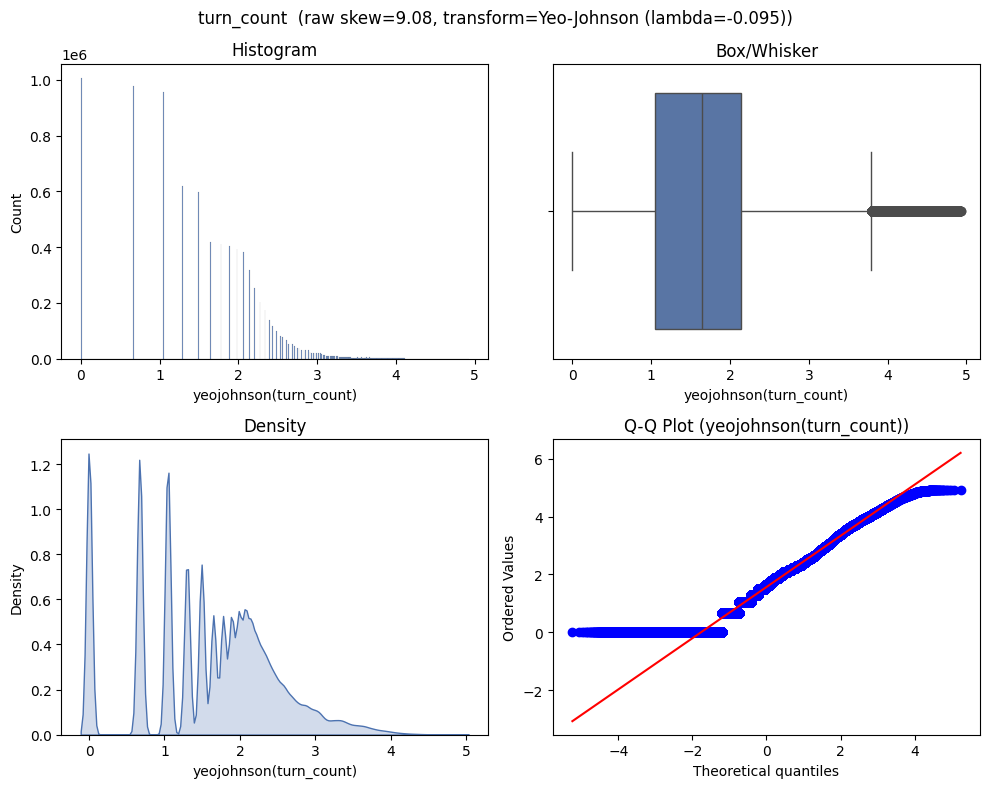

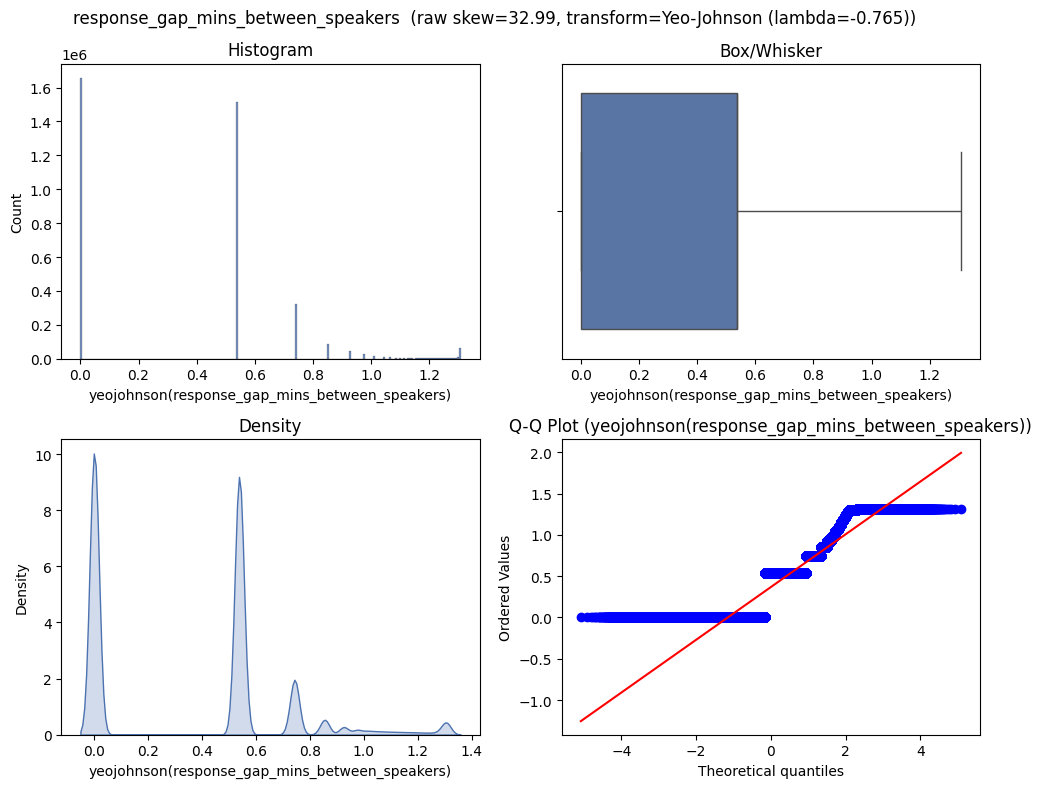

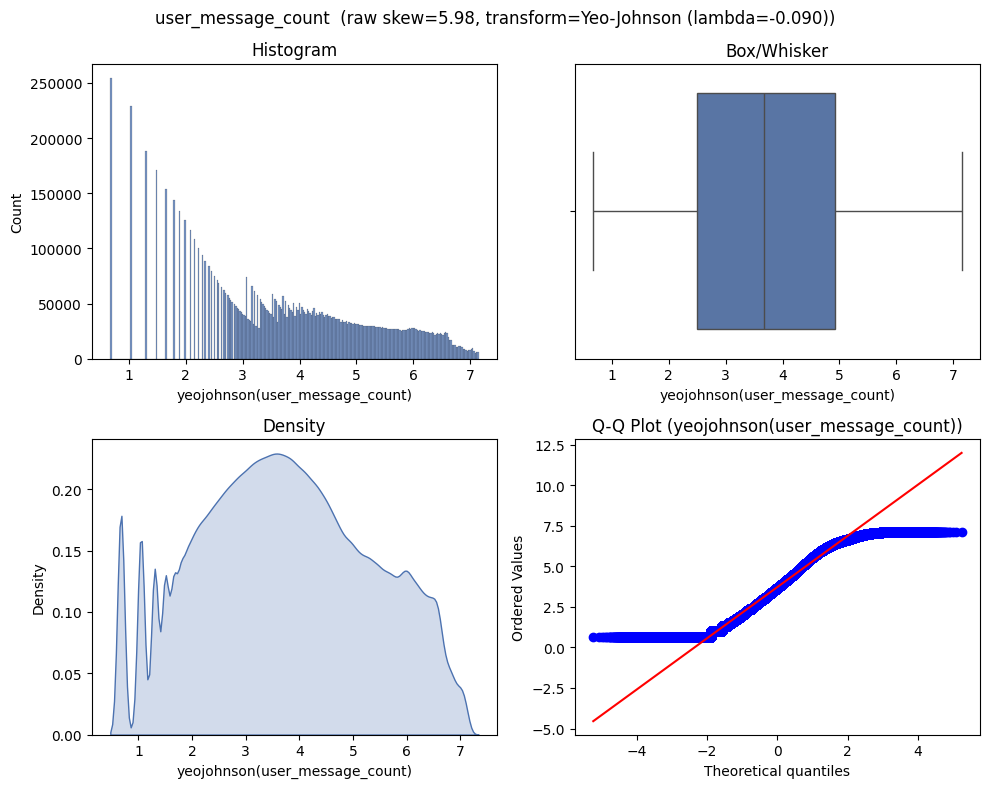

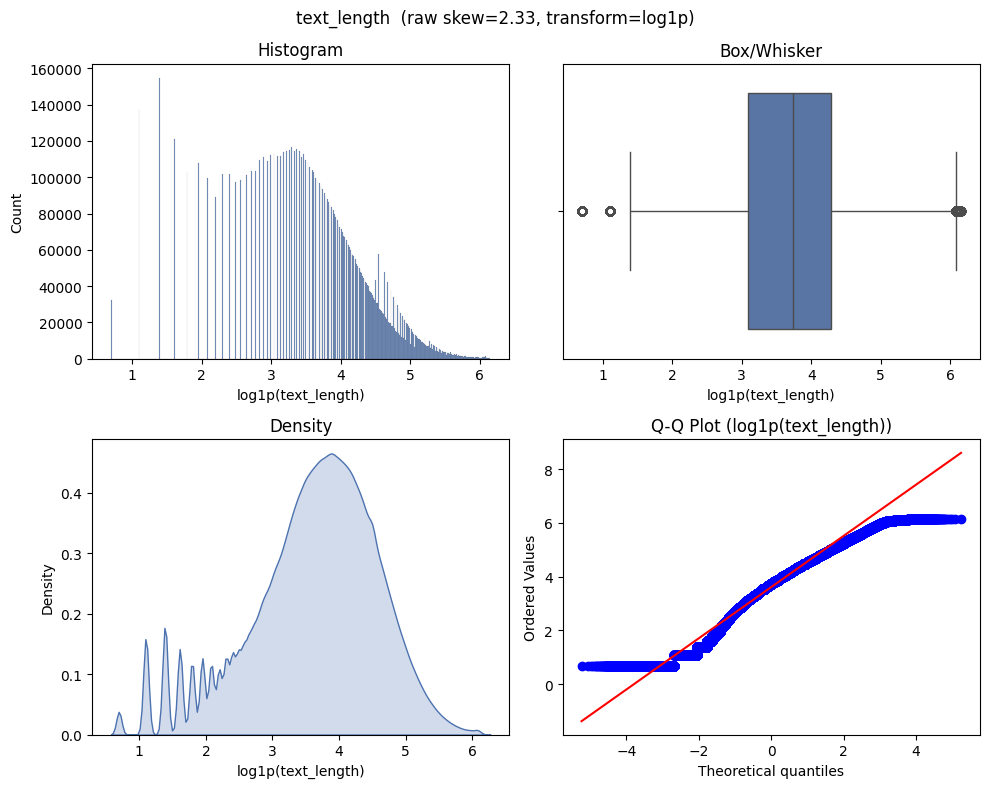

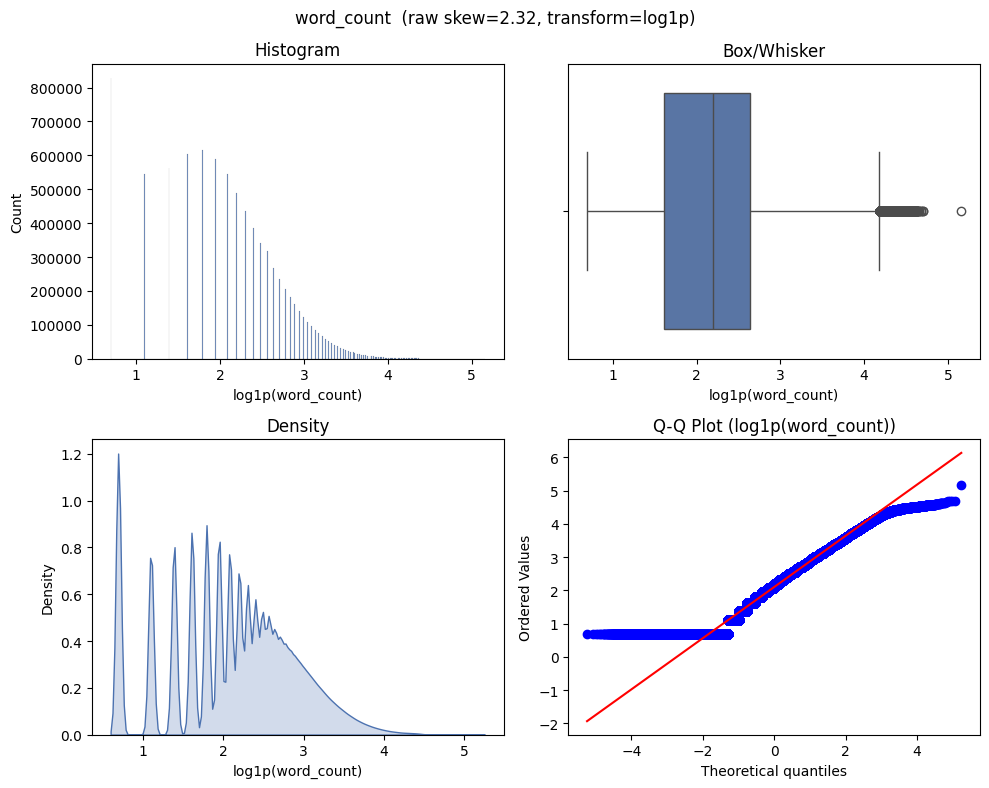

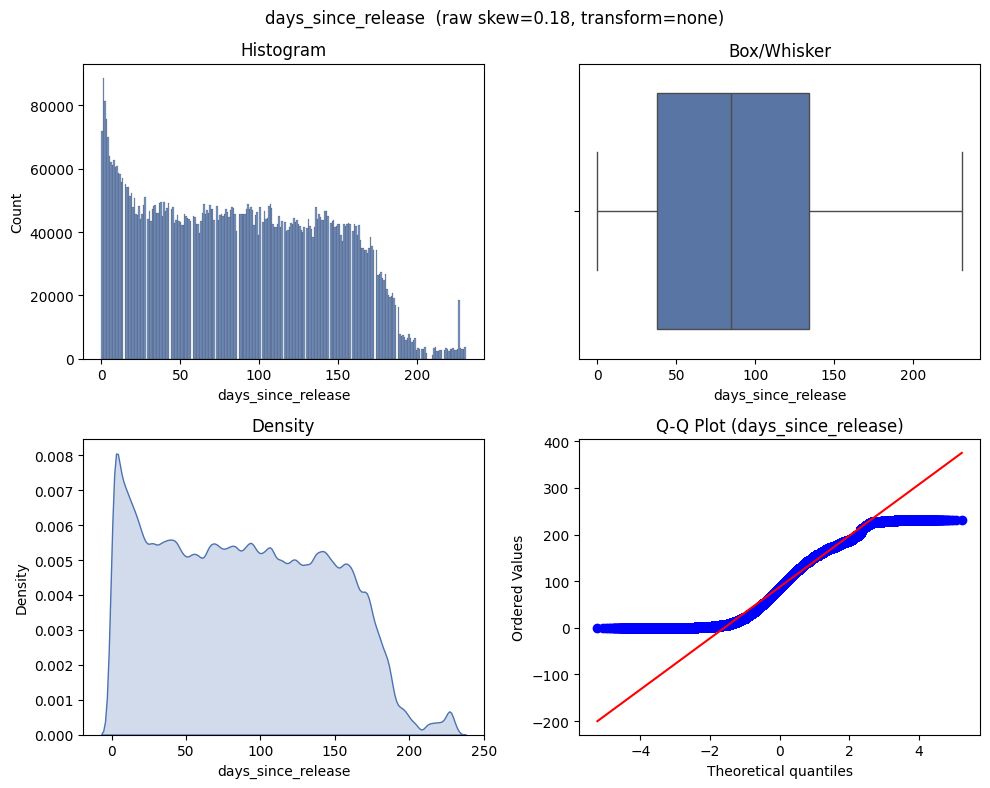

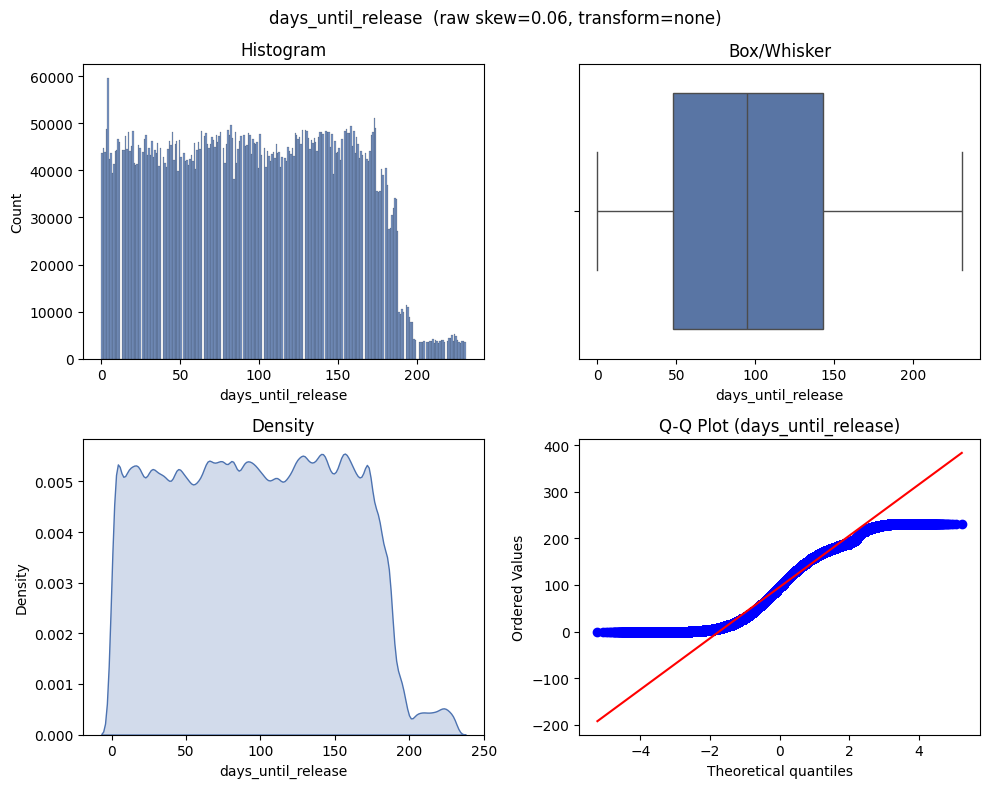

                                     transform    lambda   raw_skew
turn_count                          yeojohnson -0.094676    9.08238
response_gap_mins_between_speakers  yeojohnson  -0.76473  32.989542
user_message_count                  yeojohnson -0.090224   5.979257
text_length                              log1p      None   2.326545
word_count                               log1p      None    2.32411
days_since_release                        none      None   0.179466
days_until_release                        none      None   0.056977


In [35]:
# visuals - accounting for skewness
# histogram, box/whisker, density, Q-Q — one 2x2 grid per continuous column
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

SKEW_MODERATE = 2   # log1p above this
SKEW_SEVERE = 5      # Yeo-Johnson above this
transform_registry = {}
transformed_data = {}

for col in continuous_cols:
    data = df[col].dropna()
    raw_skew = data.skew()
    if raw_skew > SKEW_SEVERE:
        vals, lam = stats.yeojohnson(data.to_numpy())
        transformed = pd.Series(vals, index=data.index)
        transform_name = 'yeojohnson'
        label = f'yeojohnson({col})'
        transform_note = f'Yeo-Johnson (lambda={lam:.3f})'
    elif raw_skew > SKEW_MODERATE:
        transformed = np.log1p(data)
        lam = None
        transform_name = 'log1p'
        label = f'log1p({col})'
        transform_note = 'log1p'
    else:
        transformed = data
        lam = None
        transform_name = 'none'
        label = col
        transform_note = 'none'

    transform_registry[col] = {'transform': transform_name, 'lambda': lam, 'raw_skew': raw_skew}
    transformed_data[col] = transformed.reindex(df.index)
    plot_data = transformed

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f'{col}  (raw skew={raw_skew:.2f}, transform={transform_note})')
    sns.histplot(plot_data, ax=axes[0, 0], color='#4C72B0')
    axes[0, 0].set_title('Histogram'); axes[0, 0].set_xlabel(label)
    sns.boxplot(x=plot_data, ax=axes[0, 1], color='#4C72B0')
    axes[0, 1].set_title('Box/Whisker'); axes[0, 1].set_xlabel(label)
    sns.kdeplot(plot_data, ax=axes[1, 0], color='#4C72B0', fill=True)
    axes[1, 0].set_title('Density'); axes[1, 0].set_xlabel(label)
    stats.probplot(plot_data, dist='norm', plot=axes[1, 1])
    axes[1, 1].set_title(f'Q-Q Plot ({label})')
    plt.tight_layout()
    plt.show()

df_transformed = pd.DataFrame(transformed_data)
print(pd.DataFrame(transform_registry).T)


is_op -> 2 levels
         count    pct
is_op                
True   4915914  57.23
False  3673270  42.77

user_tier -> 5 levels
              count    pct
user_tier                 
regular     2862049  33.32
active      1723856  20.07
occasional  1385664  16.13
frequent    1342947  15.64
power_user  1274668  14.84

days_since_release_bucket -> 8 levels
                             count    pct
days_since_release_bucket                
8wk+                       5582979  65.00
4-6wk                       657942   7.66
6-8wk                       626717   7.30
0-1wk                       574948   6.69
1-2wk                       413496   4.81
2-3wk                       365994   4.26
3-4wk                       328585   3.83
NaN                          38523   0.45

days_until_release_bucket -> 7 levels
                             count    pct
days_until_release_bucket                
8wk+                       6057716  70.53
6-8wk                       614458   7.15
4-6wk          

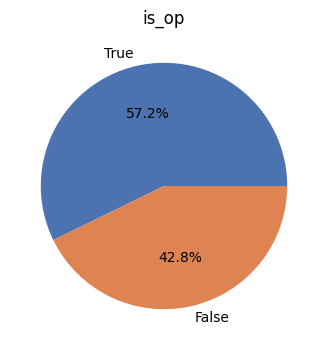

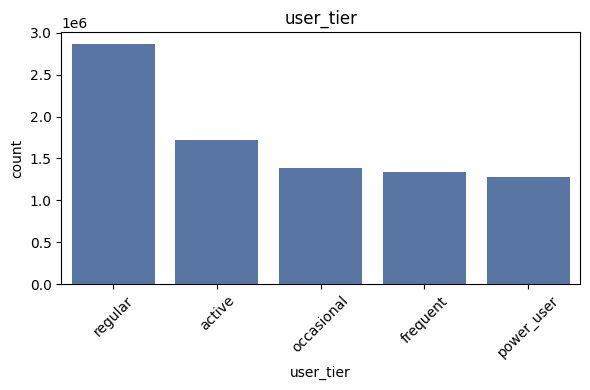

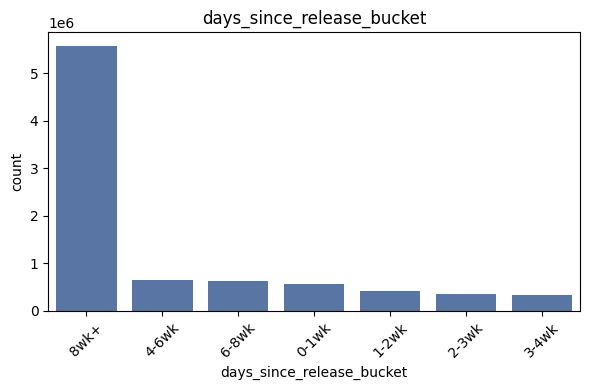

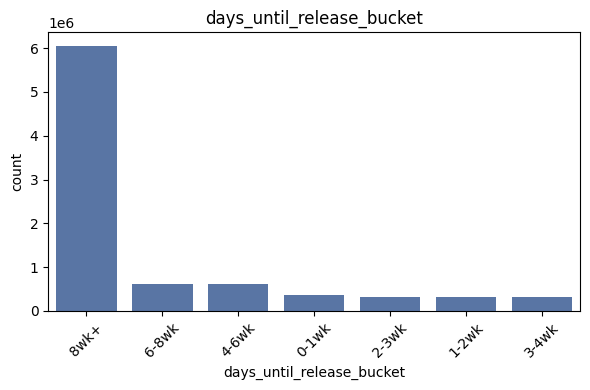

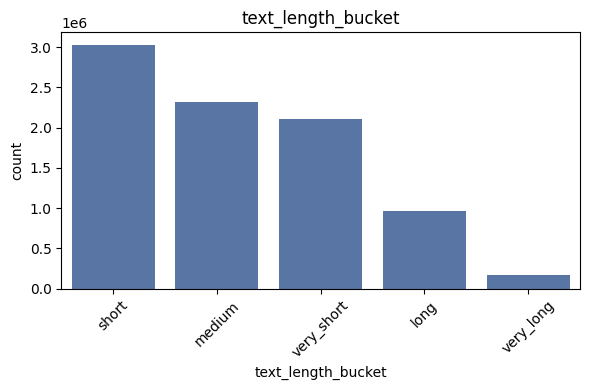

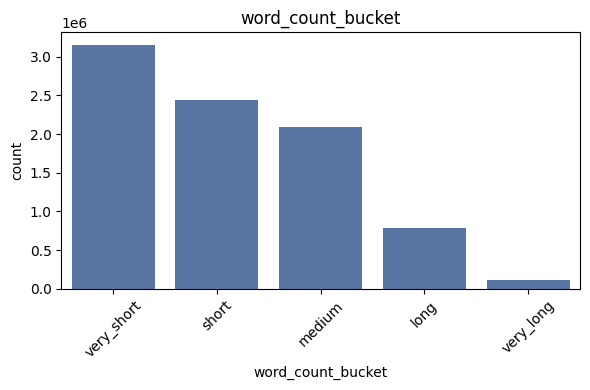

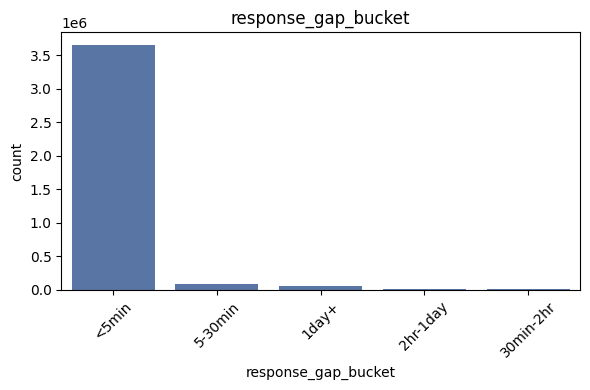

In [36]:
#Univariate Categorical - Claude
bucket_cols = ['user_tier', 'days_since_release_bucket', 'days_until_release_bucket',
               'text_length_bucket', 'word_count_bucket', 'response_gap_bucket']
categorical_cols = ['is_op'] + bucket_cols

for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    pct = (counts / len(df) * 100).round(2)
    print(f"\n{col} -> {df[col].nunique(dropna=False)} levels")
    print(pd.DataFrame({'count': counts, 'pct': pct}))

# binary categorical
fig, ax = plt.subplots(figsize=(4, 4))
df['is_op'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax, colors=['#4C72B0', '#DD8452'])
ax.set_ylabel('')
ax.set_title('is_op')
plt.show()

# multi-level categorical
for col in bucket_cols:
    fig, ax = plt.subplots(figsize=(6, 4))
    order = df[col].value_counts(dropna=True).index  # NaN excluded here
    sns.countplot(data=df, x=col, order=order, ax=ax, color='#4C72B0')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

                                    turn_count  \
turn_count                                1.00   
response_gap_mins_between_speakers        0.07   
user_message_count                        0.29   
text_length                              -0.01   
word_count                               -0.01   
days_since_release                        0.01   
days_until_release                       -0.00   

                                    response_gap_mins_between_speakers  \
turn_count                                                        0.07   
response_gap_mins_between_speakers                                1.00   
user_message_count                                                0.02   
text_length                                                       0.21   
word_count                                                        0.20   
days_since_release                                                0.01   
days_until_release                                               -0.01   

      

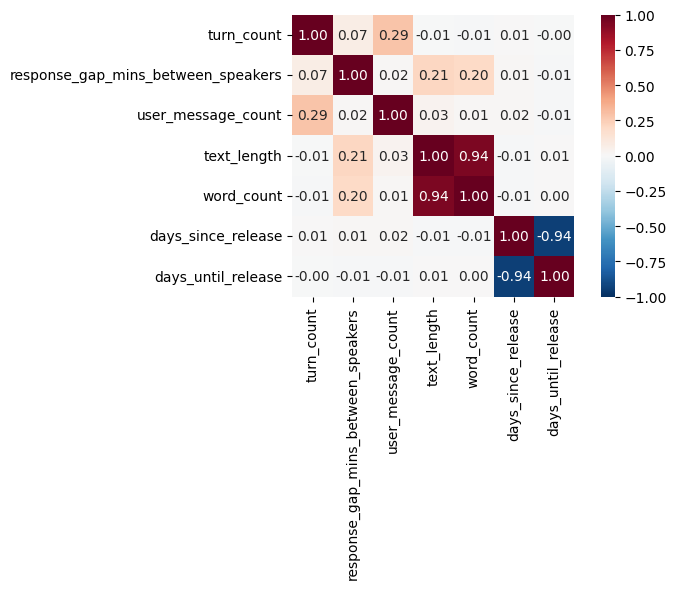

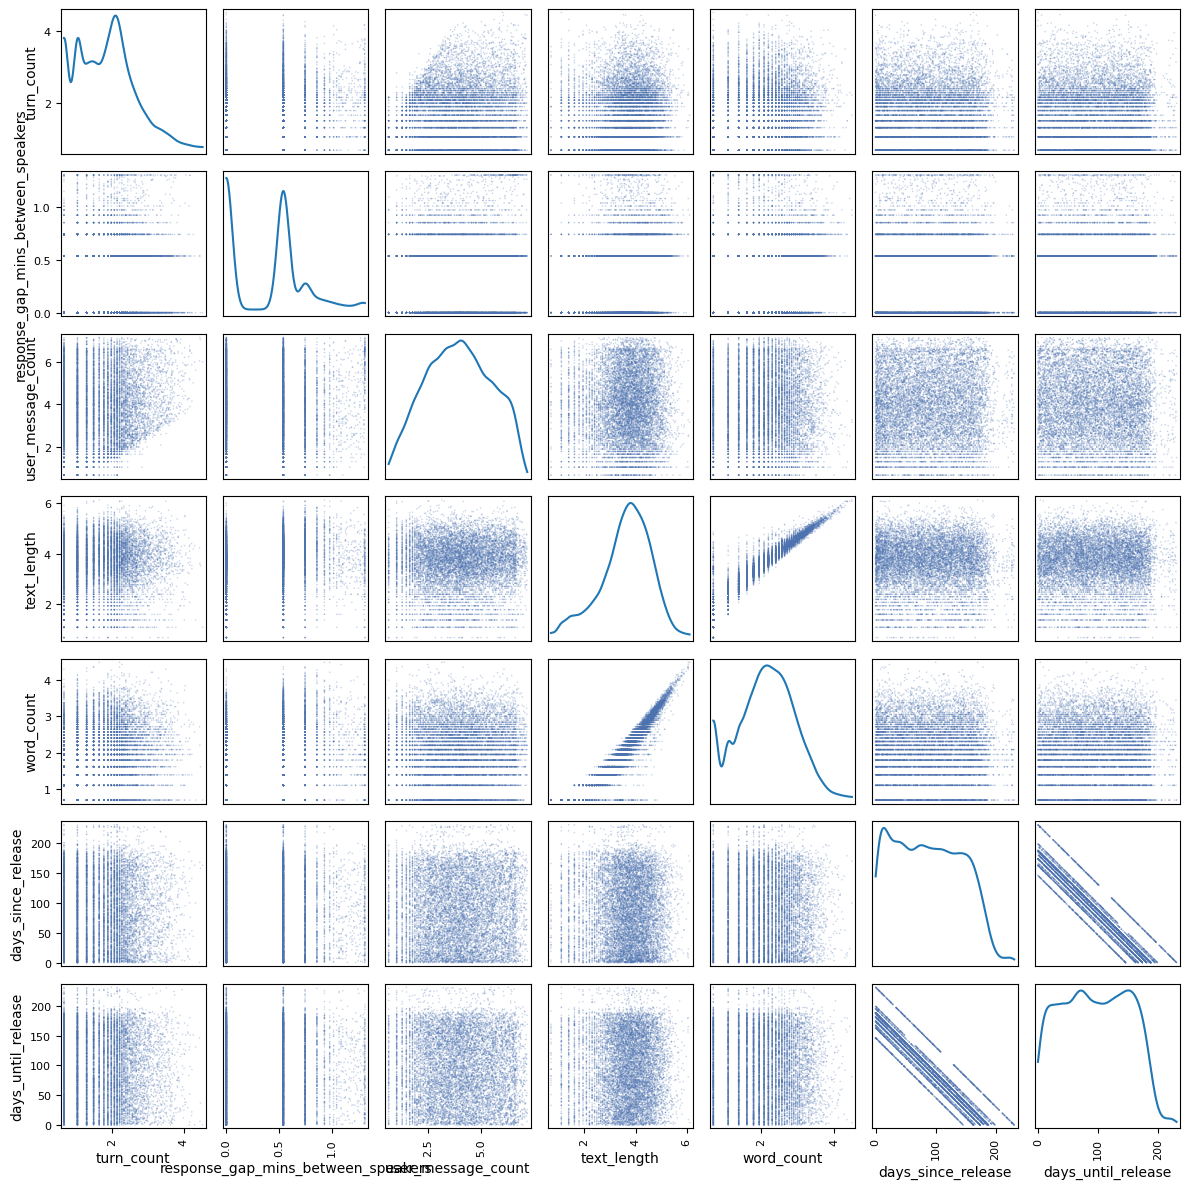

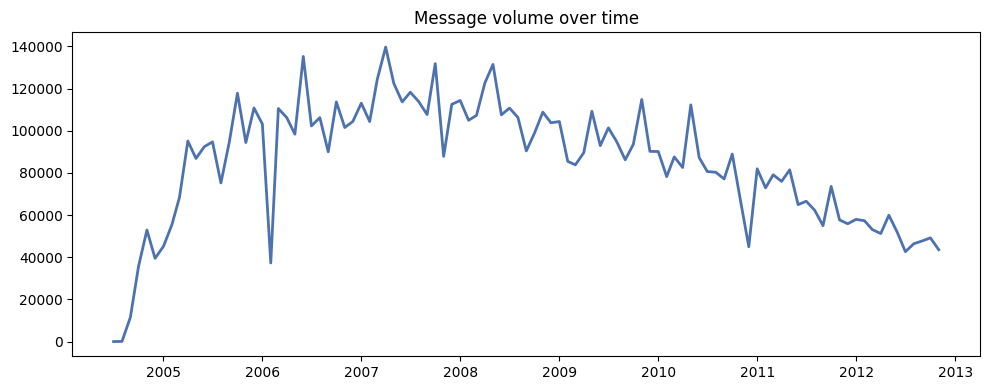

                              feature         VIF
0                          turn_count    6.347105
1  response_gap_mins_between_speakers    2.183766
2                  user_message_count    7.341148
3                         text_length  119.144405
4                          word_count   67.718963
5                  days_since_release    8.354399
6                  days_until_release    9.566210
['user_tier_regular', 'user_tier_active', 'user_tier_frequent', 'user_tier_power_user']


In [37]:
#Multivariate - Relational:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# correlations
corr_matrix = df_transformed.corr()
print(corr_matrix.round(2))

# flag pairs at |r| >= 0.5
strong_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack().reset_index()
)
strong_pairs.columns = ['var_1', 'var_2', 'corr']
strong_pairs = strong_pairs[strong_pairs['corr'].abs() >= 0.5].sort_values('corr', key=abs, ascending=False)
print(strong_pairs)

# correlation heatmap - diverging colormap, centered at 0
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
plt.tight_layout()
plt.show()

# scatter matrix on a sample - full 8.5M rows would overplot into a solid blob
sample = df_transformed.dropna().sample(n=10_000, random_state=42)
pd.plotting.scatter_matrix(sample, figsize=(12, 12), diagonal='kde',
                            color='#4C72B0', alpha=0.3, s=5)
plt.tight_layout()
plt.show()

# line chart - message volume over time
monthly = df.groupby(['year', 'month']).size().reset_index(name='message_count')
monthly['period'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))
monthly = monthly.sort_values('period')
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly['period'], monthly['message_count'], color='#4C72B0', linewidth=2)
ax.set_title('Message volume over time')
plt.tight_layout()
plt.show()

# VIF
vif_data = df_transformed.dropna()
vif_df = pd.DataFrame({
    'feature': vif_data.columns,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
})
print(vif_df)

# dummy variable trap demo
dummies = pd.get_dummies(df['user_tier'], prefix='user_tier', drop_first=True)
print(dummies.columns.tolist())

---
Patterns in the Data:
1. High correlations and VIF between text_length and word_count, may need to be combined via PCA. 
2. Days until release/Days since release also have high correlations, with less extreme VIF. 
3. Response gap in minutes between users correlates around 0.20 with message length, meaning longer messages slightly correlate with longer reply times
4. Response time maintains a median of 1 minute both between and within users across conversations. Response times within conversations may be an interesting follow-up.

---
Step 8: Data Transformation 🧱
- Reshaping (pivot, melt)
- Aggregating (groupby, agg)
- Merging (combine datasets) #N/A
- Applying Functions (apply, lambda) #N/A
- Text manipulation (str methods)

Notes:
Beyond str methods for 8e. text manipulation, I want to add supplemental columns:
- Sentiment/emotion/NLP columns to be filled later
- Separating words and messages to parse out hyperlinks, special characters, special keywords, misplaced underscores rather than spaces, slashes to separate multiple words, accommodating words that include quotations on the outside or inside (such as "happy,", "done."... other issues like "one/two", "self-important", "don't")-->  the skew value (and possibly its transform tier) will change.
These are essential for NLP analysis and appropriate word separation for sentence length, word count, etc text analysis

In [38]:
#Reshaping - Pivot Day and Hour
pd.set_option("display.max_columns", None)
day_of_week = df['date'].dt.day_name()
hour = df['date'].dt.hour

activity_pivot = pd.pivot_table(
    pd.DataFrame({'day_of_week': day_of_week, 'hour': hour, 'message_id': df['message_id']}),
    index='day_of_week', columns='hour', values='message_id', aggfunc='count'
)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
activity_pivot = activity_pivot.reindex(day_order)
print(activity_pivot)

hour            0      1      2      3      4      5      6      7      8   \
day_of_week                                                                  
Monday       36276  36308  34901  34418  34343  57628  72593  72308  72570   
Tuesday      34170  33509  34436  32678  32836  57941  72380  71743  72928   
Wednesday    34330  34598  33169  33226  33318  56735  72259  71522  71172   
Thursday     35385  34121  34437  33745  32973  59062  72370  75087  74544   
Friday       34774  36168  35517  36104  34227  59635  74863  74351  76578   
Saturday     34313  34626  34836  33608  34483  59658  71441  72068  75968   
Sunday       35450  34552  36265  34263  33551  58258  74624  76668  74874   

hour            9      10     11     12     13     14     15     16     17  \
day_of_week                                                                  
Monday       72709  69214  66741  66819  62531  62063  62185  64328  40626   
Tuesday      75170  71465  68923  64687  64463  65071  60798  6

In [39]:
#Aggregating by conversation ID 
df_sorted = df.sort_values(['conversation_id', 'date'])

conversation_summary = df_sorted.groupby('conversation_id').agg(
    message_count=('message_id', 'count'),
    num_participants=('from', 'nunique'),
    start_date=('date', 'min'),
    end_date=('date', 'max'),
    avg_text_length=('text_length', 'mean'),
    avg_word_count=('word_count', 'mean'),
    avg_response_gap_between_speakers=('response_gap_mins_between_speakers', 'mean'),
).reset_index()

conversation_summary['duration_mins'] = (conversation_summary['end_date'] - conversation_summary['start_date']).dt.total_seconds() / 60
conversation_summary['was_answered'] = conversation_summary['num_participants'] > 1

# ended_by_op: who sent the LAST message in the conversation
last_message = df_sorted.groupby('conversation_id').tail(1)
ended_by_op = last_message.set_index('conversation_id')['is_op']
conversation_summary['ended_by_op'] = conversation_summary['conversation_id'].map(ended_by_op)

In [40]:
conversation_summary.head()

,conversation_id,message_count,num_participants,start_date,end_date,avg_text_length,avg_word_count,avg_response_gap_between_speakers,duration_mins,was_answered,ended_by_op
0,1,3,2,2005-05-25 11:26:00,2005-05-25 11:27:00,46.333333,8.666667,0.5,1.0,True,True
1,2,1,1,2004-11-04 16:49:00,2004-11-04 16:49:00,61.000000,12.000000,NaN,0.0,False,True
2,3,1,1,2005-03-02 15:34:00,2005-03-02 15:34:00,15.000000,3.000000,NaN,0.0,False,True
3,4,3,2,2005-06-03 07:24:00,2005-06-03 07:25:00,68.333333,14.000000,1.0,1.0,True,False
4,5,3,2,2005-01-14 16:28:00,2005-01-14 16:30:00,22.000000,4.333333,1.0,2.0,True,True


In [41]:
print(conversation_summary['was_answered'].value_counts())

was_answered
True     945379
False     62979
Name: count, dtype: int64


In [42]:
#Examine conversations according to counts for messages and duration in days
answered = conversation_summary[conversation_summary['was_answered']].copy()
answered['duration_days'] = answered['duration_mins'] / 1440   # 1440 minutes per day

print(answered[['message_count', 'duration_days']].describe())

       message_count  duration_days
count  945379.000000  945379.000000
mean        8.903826      14.048837
std        10.257723      96.175921
min         2.000000       0.000000
25%         3.000000       0.001389
50%         5.000000       0.002778
75%        12.000000       0.009722
max       760.000000    2655.758333


In [43]:
#create categorical bins for conversations where the original message is answered by the recipient at least once
mc_bins = [1, 2, 5, 12, 30, 100, float('inf')]
mc_labels = ['2', '3-5', '6-12', '13-30', '31-100', '100+']
answered['message_count_bucket'] = pd.cut(answered['message_count'], bins=mc_bins, labels=mc_labels)

dur_bins = [-0.001, 5/1440, 30/1440, 2/24, 1, 7, 30, 365, float('inf')]
dur_labels = ['<5min', '5-30min', '30min-2hr', '2hr-1day', '1-7days', '7-30days', '30-365days', '1yr+']
answered['duration_bucket'] = pd.cut(answered['duration_days'], bins=dur_bins, labels=dur_labels)

print(answered['message_count_bucket'].value_counts(normalize=True).sort_index())
print(answered['duration_bucket'].value_counts(normalize=True).sort_index())

message_count_bucket
2         0.013229
3-5       0.549645
6-12      0.224587
13-30     0.189392
31-100    0.021455
100+      0.001692
Name: proportion, dtype: float64
duration_bucket
<5min         0.566863
5-30min       0.273675
30min-2hr     0.052689
2hr-1day      0.027092
1-7days       0.018879
7-30days      0.015697
30-365days    0.032828
1yr+          0.012277
Name: proportion, dtype: float64


---
Also building an aggregate table per user. These two tables will be joined, not merged, with the primary table based on "conversation_id" and "username" derived from the 'to' and 'from' columns, 

For the user table, we can create columns:
- the count and rate of conversations where they are OP, 
- how many messages they sent vs received overall count and average per conversation, 
- month of most messages sent (same for year), 
- average time to respond to other's messages,
- rate of messages sent based on the range they were active: eg a user active from 2005-2010 rate would be relative to those years
- avg word count, avg text length

For aggregate tables, once we perform sentiment/emotion/advanced NLP analysis, we can build profiles on users, conversations, and messages.

In [44]:
#Aggregate Users Table
sent_agg = df.groupby('from').agg(
    messages_sent=('message_id', 'count'),
    conversations_sent_in=('conversation_id', 'nunique'),
    avg_word_count=('word_count', 'mean'),
    avg_text_length=('text_length', 'mean'),
    first_message_date=('date', 'min'),
    last_message_date=('date', 'max'),
    avg_response_time_mins=('response_gap_mins_between_speakers', 'mean'),
).reset_index().rename(columns={'from': 'user'})

op_conversations = (df[df['is_op']]
                     .groupby('from')['conversation_id']
                     .nunique()
                     .rename('op_conversations'))
sent_agg = sent_agg.merge(op_conversations, left_on='user', right_index=True, how='left')
sent_agg['op_conversations'] = sent_agg['op_conversations'].fillna(0)
sent_agg['op_rate'] = sent_agg['op_conversations'] / sent_agg['conversations_sent_in']

most_common_month = df.groupby('from')['month'].agg(lambda s: s.value_counts().idxmax()).rename('most_common_month')
most_common_year = df.groupby('from')['year'].agg(lambda s: s.value_counts().idxmax()).rename('most_common_year')
sent_agg = sent_agg.merge(most_common_month, left_on='user', right_index=True, how='left')
sent_agg = sent_agg.merge(most_common_year, left_on='user', right_index=True, how='left')

received_counts = df.groupby('to').agg(
    messages_received=('message_id', 'count'),
    conversations_received_in=('conversation_id', 'nunique'),
)
sent_agg = sent_agg.merge(received_counts, left_on='user', right_index=True, how='left')
sent_agg[['messages_received', 'conversations_received_in']] = sent_agg[['messages_received', 'conversations_received_in']].fillna(0)

sent_agg['avg_sent_per_conversation'] = sent_agg['messages_sent'] / sent_agg['conversations_sent_in']
sent_agg['avg_received_per_conversation'] = sent_agg['messages_received'] / sent_agg['conversations_received_in'].replace(0, np.nan)

sent_agg['active_range_days'] = (
    (sent_agg['last_message_date'] - sent_agg['first_message_date']).dt.total_seconds() / 86400
)
sent_agg['messages_per_active_day'] = sent_agg['messages_sent'] / sent_agg['active_range_days'].replace(0, np.nan)

user_summary = sent_agg

In [45]:
user_summary.nlargest(5, 'avg_text_length') #Examine

,user,messages_sent,conversations_sent_in,avg_word_count,avg_text_length,first_message_date,last_message_date,avg_response_time_mins,op_conversations,op_rate,most_common_month,most_common_year,messages_received,conversations_received_in,avg_sent_per_conversation,avg_received_per_conversation,active_range_days,messages_per_active_day
219092,e0aj2,4,1,78.25,467.0,2011-05-31 02:52:00,2011-05-31 02:52:00,0.0,1.0,1.0,5,2011,1.0,1.0,4.0,1.0,0.0,NaN
122555,irc5847,1,1,64.00,465.0,2008-08-03 02:17:00,2008-08-03 02:17:00,NaN,1.0,1.0,8,2008,1.0,1.0,1.0,1.0,0.0,NaN
64125,jedus,2,1,58.00,464.0,2009-07-21 00:05:00,2009-07-21 00:05:00,NaN,1.0,1.0,7,2009,1.0,1.0,2.0,1.0,0.0,NaN
192075,kdhbne12,4,1,35.50,464.0,2011-01-24 01:00:00,2011-01-24 01:00:00,0.0,1.0,1.0,1,2011,1.0,1.0,4.0,1.0,0.0,NaN
210818,edhjrw,3,1,66.00,464.0,2011-05-16 20:13:00,2011-05-16 20:13:00,NaN,1.0,1.0,5,2011,2.0,1.0,3.0,2.0,0.0,NaN


---
Above, I have made a pivot table to discover hourly and day-of-week trends, beyond the monthly and yearly trends from earlier steps. In this table, you see that UTC hours 6-9 have the highest counts of message IDs, on average at around 70,000 messages taking place during this time across all days of the week. Conversely, there are steep drops between hours 16 and 17, and 17 and 18... and a sharp increase between hours 5 and 6 (each of these is +/-10,000 messages being sent between the hour marks). The differences between days of the week are less noticeable per hour, all within ranges less than 10,000. This probes interest in further analysis. The values in this table are counts, but I would like to view the averages, and discover why these trends are happening, and what's being discussed during peak or low hours. 

Then, I created aggregate tables for both conversation-level and user-level data. This will make it easy to examine trends on the conversation- and user- level and build out profiles. 

Next is Text Manipulation (my favorite part 😊):
- the main tasks are first discerning what issues exist within the text. As noted above, there are typos, hyperlinks being recognized as words, words separated by slashes being considered as a single word, other issues with characters. My thought is to subset the data by messages with any non-alphabet characters, and separate those further depending on the characters present, beginning with the most obscure and then getting more general. I'm hoping that throughout this process, I can also begin to find what terms would be fitting for the lexicon and other types of terminology or patterns to look out for.
- after ensuring the text is up to par and the lexicon is looking robust, I would like to begin with spacy, and do part of speech tagging, particularly for proper nouns from the lexicon, which will likely constitute the main topics.
- then, I would like to identify emotion-rich words in the text that could identify feelings or frequent comments in relation to those topics, and begin sentiment/emotional analysis.

In [46]:
#Identify non-letter characters
from collections import Counter
from itertools import chain

non_alpha = df['text'].str.findall(r"[^A-Za-z ]")
char_counts = Counter(chain.from_iterable(non_alpha.dropna()))
char_freq = pd.Series(char_counts).sort_values()

In [47]:
print(char_freq)
#print(char_freq.to_string()) #for full list

經          1
ŀ          1
इ          1
ई          1
ť          1
      ...   
/    2038402
?    2356284
,    2903298
'    2909595
.    5824967
Length: 2334, dtype: int64


In [48]:
import re
target_char = char_freq.index[0]
example_rows = df[df['text'].str.contains(re.escape(target_char), na=False)]
print(example_rows)

         message_id  conversation_id                date         from  \
7294169     7294170           982218 2010-10-20 21:27:00  rypervenche   

                    to  \
7294169  ubuntu91human   

                                                                                                                                           text  \
7294169  That's not what I'm looking for. I can already do that. 已經會用中文打字. I'm looking to type out bopomofo for helping people pronounce words.   

         turn_count  is_op  response_gap_mins  user_message_count  \
7294169           5   True                2.0                  98   

         text_length  word_count  days_since_release  days_until_release  \
7294169          134          23                10.0                 189   

         response_gap_mins_between_speakers  year  month  \
7294169                                 2.0  2010     10   

        days_since_release_bucket days_until_release_bucket  \
7294169                     1

In [49]:
df = df.drop(example_rows.index) #only a single row

In [50]:
#Classify characters
import unicodedata

def classify_char(ch):
    if ch.isascii():
        if ch.isdigit():
            return 'digit'
        if ch.isalpha():
            return 'latin_letter'
        return 'ascii_punct_symbol'
    try:
        name = unicodedata.name(ch)
    except ValueError:
        return 'unnamed_control_or_formatting'
    cat = unicodedata.category(ch)
    if ch == '\ufffd':
        return 'encoding_artifact (replacement char)'
    if cat.startswith('M'):
        return 'combining_mark'
    if cat == 'Cf':
        return 'zero_width_format_char'
    if cat in ('Ll', 'Lu') and 'LATIN' in name:
        return 'accented_latin_letter'
    for keyword, label in [
        ('CJK', 'han_chinese_japanese_kanji'),
        ('HIRAGANA', 'japanese_hiragana'),
        ('KATAKANA', 'japanese_katakana'),
        ('HANGUL', 'korean_hangul'),
        ('CYRILLIC', 'cyrillic'),
        ('ARABIC', 'arabic'),
        ('HEBREW', 'hebrew'),
        ('GREEK', 'greek'),
        ('THAI', 'thai'),
        ('DEVANAGARI', 'devanagari'),
        ('ARMENIAN', 'armenian'),
        ('GEORGIAN', 'georgian'),
        ('ETHIOPIC', 'ethiopic'),
        ('TAMIL', 'tamil'),
        ('MALAYALAM', 'malayalam'),
        ('SINHALA', 'sinhala'),
        ('CANADIAN SYLLABICS', 'canadian_aboriginal_syllabics'),
        ('BRAILLE', 'braille'),
        ('BOX DRAWINGS', 'box_drawing'),
        ('MATHEMATICAL', 'stylized_math_alphanumeric'),
        ('FULLWIDTH', 'fullwidth_latin_variant'),
    ]:
        if keyword in name:
            return label
    if cat.startswith('S'):
        return 'symbol_or_emoji'
    return f'other:{cat}:{name[:25]}'

char_categories = char_freq.index.to_series().apply(classify_char)
category_summary = char_freq.groupby(char_categories.values).sum().sort_values(ascending=False)
print(category_summary.to_string())

ascii_punct_symbol                      21732778
digit                                    4459090
accented_latin_letter                      14274
cyrillic                                   12548
han_chinese_japanese_kanji                  6132
zero_width_format_char                      5757
symbol_or_emoji                             5205
other:Pf:RIGHT-POINTING DOUBLE ANG          2981
other:Pi:LEFT-POINTING DOUBLE ANGL          2792
combining_mark                              2433
arabic                                      2344
other:Po:INVERTED QUESTION MARK             2066
encoding_artifact (replacement char)        1945
other:Po:HORIZONTAL ELLIPSIS                1161
greek                                       1074
other:Zs:NO-BREAK SPACE                     1012
other:Pf:RIGHT SINGLE QUOTATION MA           767
box_drawing                                  714
fullwidth_latin_variant                      682
korean_hangul                                489
other:Pf:RIGHT DOUBL

In [51]:
#Categorize symbols
EMOJI_RANGES = [
    (0x1F300, 0x1F5FF), (0x1F600, 0x1F64F), (0x1F680, 0x1F6FF),
    (0x1F900, 0x1F9FF), (0x1FA70, 0x1FAFF), (0x2600, 0x26FF),
    (0x2700, 0x27BF), (0x1F1E6, 0x1F1FF),
]
CURRENCY_SYMBOLS = set('$¢£¤¥₠€₹₽₿')
MATH_SYMBOLS = set('±×÷√∞≤≥≠∈∑∂∇')
LEGAL_TECH_SYMBOLS = set('©®™§¶')
DEGREE_SYMBOLS = set('°℃℉')

def is_emoji(ch):
    cp = ord(ch)
    return any(lo <= cp <= hi for lo, hi in EMOJI_RANGES)

def classify_char(ch):
    if ch.isascii():
        if ch.isdigit(): return 'digit'
        if ch.isalpha(): return 'latin_letter'
        return 'ascii_punct_symbol'
    try:
        name = unicodedata.name(ch)
    except ValueError:
        return 'unnamed_control_or_formatting'
    cat = unicodedata.category(ch)

    if ch == '\ufffd': return 'encoding_artifact (replacement char)'
    if is_emoji(ch): return 'pictographic_emoji'
    if ch in CURRENCY_SYMBOLS: return 'currency_symbol'
    if ch in MATH_SYMBOLS: return 'math_symbol'
    if ch in LEGAL_TECH_SYMBOLS: return 'legal_technical_symbol'
    if ch in DEGREE_SYMBOLS: return 'degree_temperature_symbol'
    if cat == 'No' and ('FRACTION' in name or 'SUPERSCRIPT' in name or 'SUBSCRIPT' in name):
        return 'number_form (fraction/exponent)'
    if cat.startswith('M'): return 'combining_mark'
    if cat == 'Cf': return 'zero_width_format_char'
    if cat in ('Ll', 'Lu') and 'LATIN' in name: return 'accented_latin_letter'
    if 'IDEOGRAPHIC' in name or 'FULLWIDTH' in name: return 'cjk_typographic_punctuation'
    if cat in ('Pi', 'Pf', 'Pd', 'Ps', 'Pe', 'Pc', 'Po'):
        return 'typographic_punctuation (quotes/dashes/etc)'
    if cat == 'Zs': return 'unusual_whitespace'
    for keyword, label in [
        ('CJK', 'han_chinese_japanese_kanji'), ('HIRAGANA', 'japanese_hiragana'),
        ('KATAKANA', 'japanese_katakana'), ('HANGUL', 'korean_hangul'),
        ('CYRILLIC', 'cyrillic'), ('ARABIC', 'arabic'), ('HEBREW', 'hebrew'),
        ('GREEK', 'greek'), ('THAI', 'thai'), ('DEVANAGARI', 'devanagari'),
        ('ARMENIAN', 'armenian'), ('GEORGIAN', 'georgian'), ('ETHIOPIC', 'ethiopic'),
        ('TAMIL', 'tamil'), ('MALAYALAM', 'malayalam'), ('SINHALA', 'sinhala'),
        ('BRAILLE', 'braille'), ('BOX DRAWINGS', 'box_drawing'),
        ('MATHEMATICAL', 'stylized_math_alphanumeric'),
    ]:
        if keyword in name: return label
    if cat.startswith('S'): return 'other_symbol'
    return f'other:{cat}:{name[:25]}'

char_categories = char_freq.index.to_series().apply(classify_char)
category_summary = char_freq.groupby(char_categories.values).sum().sort_values(ascending=False)
print(category_summary)
#print(category_summary.to_string()) #paste this in a below cell for full list

ascii_punct_symbol                             21732778
digit                                           4459090
accented_latin_letter                             14274
cyrillic                                          12548
typographic_punctuation (quotes/dashes/etc)       11758
                                                 ...   
other:Nd:NKO DIGIT TWO                                1
other:Nd:GUJARATI DIGIT ZERO                          1
other:Lu:DOUBLE-STRUCK ITALIC CAPI                    1
other:Nd:KANNADA DIGIT ZERO                           1
other:Nd:LAO DIGIT SEVEN                              1
Length: 117, dtype: int64


In [52]:
#Replace characters with frequency less than 10 in the entire dataset with a flower emoji - temporary for text_cleaned
rare_chars = char_freq[char_freq < 10].index.tolist()
pattern = '[' + ''.join(re.escape(c) for c in rare_chars) + ']'
df['text_cleaned'] = df['text'].str.replace(pattern, '🪻', regex=True)

In [53]:
df[df['text_cleaned'].str.contains('🪻', na=False)][['message_id', 'conversation_id', 'date', 'from', 'to', 'text','text_cleaned']] #examine

,message_id,conversation_id,date,from,to,text,text_cleaned
11737,11738,4015,2012-09-07 05:22:00,Bing,__ALL__,现在有可用的QQ么？,🪻在有可用的QQ么？
11738,11739,4015,2012-09-07 05:22:00,Bing,wilee-nilee,pidgin怎么又不能用了....,pidgin怎么🪻不能用了....
12387,12388,4236,2012-09-05 18:50:00,ZhDong,__ALL__,win 的程序可以在ubuntu上安装吗？,win 的🪻🪻可以在ubuntu上安装吗？
16078,16079,5502,2012-03-12 01:14:00,aperson,__ALL__,bouzbou➽ you need to chroot and install grub from there,bouzbou🪻 you need to chroot and install grub from there
16607,16608,5683,2012-03-04 16:19:00,elham,__ALL__,Inaayat99✌ does ur problem solved about chrome ?,Inaayat99🪻 does ur problem solved about chrome ?
...,...,...,...,...,...,...,...
8365792,8365793,1006823,2008-01-06 17:01:00,david919,khermans,"i dont know how else to explain it, the jargon assed fonts eg ⎽┤␍⎺ ▒␋⎼␊⎻┌▒≤-┼± -1 0 -␊ ⎽610205 -▒ 00:0E:9B:43:###","i dont know how else to explain it, the jargon assed fonts eg 🪻🪻🪻🪻 ▒🪻🪻🪻🪻┌▒🪻-🪻± -1 0 -🪻 🪻610205 -▒ 00:0E:9B:43:###"
8381048,8381049,1006973,2008-02-23 13:06:00,icesword,bazhang,is it （support) your job? or something interest?,is it 🪻support) your job? or something interest?
8403976,8403977,1007187,2012-07-17 07:32:00,jagginess,DarkAceZ,[✔] ?,[🪻] ?
8451142,8451143,1007590,2008-02-19 05:48:00,icesword,nickrud,"hi,is this （support this channel) your job?","hi,is this 🪻support this channel) your job?"


---
Im thinking for the cleaned text column... if theres entire words/characters in another language, they should be replaced with their character category like (CYRILLIC). not per character, but until a space or punctuation symbol interrupts it. 

As I review these, I'm discovering sometimes characters like :Д and ヅ are flagging as languages, even though they are used in these cases as emoticons.
Fixing language-based issues like this as I review.

In [54]:
#Spot replacing emojis that feature characters from other languages
def qualifying_conversations(df, char_categories, label, target_char):
    label_chars = sorted(char_categories[char_categories == label].index.tolist())
    flags = pd.DataFrame(index=df.index)
    for ch in label_chars:
        flags[ch] = df['text'].str.contains(re.escape(ch), na=False, regex=True)
    conv_flags = flags.groupby(df['conversation_id']).any()
    num_distinct = conv_flags.sum(axis=1)
    qualifying = conv_flags[(num_distinct == 1) & (conv_flags.get(target_char, False))].index
    return set(qualifying)

cyr_qualifying = qualifying_conversations(df, char_categories, 'cyrillic', 'Д')
kata_qualifying = qualifying_conversations(df, char_categories, 'japanese_katakana', 'ヅ')

df['text_cleaned'] = df['text']

cyr_mask = df['conversation_id'].isin(cyr_qualifying)
df.loc[cyr_mask, 'text_cleaned'] = df.loc[cyr_mask, 'text_cleaned'].str.replace(
    r'(^|\s):Д(\s|$)', r'\1:)\2', regex=True
)

kata_mask = df['conversation_id'].isin(kata_qualifying)
df.loc[kata_mask, 'text_cleaned'] = df.loc[kata_mask, 'text_cleaned'].str.replace(
    r'(^|\s)ヅ(\s|$)', r'\1:)\2', regex=True
)

In [55]:
#Language labels
NON_LATIN_LABELS = ['han_chinese_japanese_kanji','japanese_hiragana','japanese_katakana',
                     'korean_hangul','cyrillic','arabic','hebrew','greek','thai','devanagari',
                     'armenian','georgian','ethiopic','malayalam','tamil','sinhala']

for label in NON_LATIN_LABELS:
    chars = char_categories[char_categories == label].index.tolist()
    if not chars:
        continue
    pattern = '[' + ''.join(re.escape(c) for c in chars) + ']+'
    token = label.upper()
    df['text_cleaned'] = df['text_cleaned'].str.replace(pattern, token, regex=True)

In [56]:
#For non-latin language labels many times in sequence, compress to one single label:
for label in NON_LATIN_LABELS:
    token = label.upper()
    pattern = rf'\b{re.escape(token)}(?:\s+{re.escape(token)})+\b'
    df['text_cleaned'] = df['text_cleaned'].str.replace(pattern, token, regex=True)

In [57]:
label_pattern = '|'.join(label.upper() for label in NON_LATIN_LABELS)

In [58]:
df[df['text_cleaned'].str.contains(label_pattern, na=False, regex=True)][['message_id', 'conversation_id', 'date', 'from', 'to', 'text', 'text_cleaned']].sample(n=5) #examine

,message_id,conversation_id,date,from,to,text,text_cleaned
1444639,1444640,442214,2010-10-07 17:28:00,huitailang,__ALL__,大家好,HAN_CHINESE_JAPANESE_KANJI
1416404,1416405,436138,2009-12-12 12:31:00,Nisa,FloodBot1,>�yOZ�y�_��h$����@?-;p�\d��s*=�Ҙ�iA:�?ǰi�|��YjU_J1@����Ѥ_)e ��~B�C��3��I�0�]���G�_f�Ղ91L��Պ.^e;Eʲ���5� ��g8���l&*j^� 姘W]�run �(�N�����7X�\�X����^��l)��}R覊�����-U����s,>�yOZ�y�_��h$����@?-;p�\d��s*=�CYRILLIC�iA:�?ǰi�|��YjU_J1@����CYRILLIC_)e ��~B�C��3��I�0�]���G�_f�ARMENIAN91L��ARMENIAN.^e;Eʲ���5� ��g8���l&*j^� HAN_CHINESE_JAPANESE_KANJIW]�run �(�N�����7X�\�X����^��l)��}RHAN_CHINESE_JAPANESE_KANJI�����-U����s
924351,924352,321781,2012-07-06 14:05:00,zhoumao,magpie,我打了那个指令 是不是就进入了CN频道,HAN_CHINESE_JAPANESE_KANJI HAN_CHINESE_JAPANESE_KANJICNHAN_CHINESE_JAPANESE_KANJI
1805235,1805236,519922,2009-11-17 11:29:00,elvis,Flannel,бля,CYRILLIC
3306868,3306869,704907,2009-05-16 12:36:00,playboy,Flannel,你好,HAN_CHINESE_JAPANESE_KANJI


In [59]:
df[['message_id', 'conversation_id', 'date', 'from', 'to', 'text', 'text_cleaned']].sample(n=10) #examine

,message_id,conversation_id,date,from,to,text,text_cleaned
2482314,2482315,612215,2005-11-19 13:40:00,OptiPlex,Seveas,"mmorpg's made me want cable a few months back, but now ubuntu REALLY makes me want cable :]","mmorpg's made me want cable a few months back, but now ubuntu REALLY makes me want cable :]"
6002387,6002388,921252,2006-03-06 06:03:00,pbransford,kc2keo,in Phlak i set it to monitor mode and the blink pattern changed but I didn't try sniffing,in Phlak i set it to monitor mode and the blink pattern changed but I didn't try sniffing
4601522,4601523,825017,2012-08-31 03:20:00,subz3r0,histo,thx,thx
8532351,8532352,1008131,2006-05-22 13:08:00,livingdaylight,crimsun,does having FireFox open conflict?,does having FireFox open conflict?
5531186,5531187,891280,2008-07-20 12:18:00,Agent_bob,simplemotives,!ask > DTOPSB,!ask > DTOPSB
325790,325791,112685,2009-10-19 07:31:00,jode,Izinucs,yes,yes
3808698,3808699,754779,2007-05-13 15:48:00,Tonnerre,leperkhanz,"But if I execute the _same_ command line it executes, as the same user, OpenVPN establishes a connection I can use","But if I execute the _same_ command line it executes, as the same user, OpenVPN establishes a connection I can use"
4798850,4798851,839397,2008-05-07 19:59:00,AlphaOmega,hydrogen,i think i will,i think i will
2180955,2180956,578940,2012-09-29 16:40:00,bekks,Erealz,snort is not a packetfilter.,snort is not a packetfilter.
508102,508103,176212,2007-07-22 10:11:00,Nicke,FFForever,du -sh folder,du -sh folder


I refreshed the above sample many times to begin developing the Ubuntu jargon lexicon, then provided it to AI to round out prevalent developer terms that are relevant to this era of the internet. Further, I built a lexicon for slang that was common at the time, as well as emojis, kaomojis, emoticons, and stylistic characters that imbue meaning and can and should influence message sentiment. 

The next step is applying these symbolic interpretations to text detection before interpretation. Messages containing the placeholder emoji, 🪻, which was released in 2022 (after the most recent message in the dataset and therefore entirely unique), will be re-examined within context of both the message itself and its language, and the slang lexicon. 

Another development was creating templates for emails, website domains, phone numbers, SSNs units of measurement, and IP addresses, so that these can be parsed and recognized by the program. This was worthwhile for this dataset and as a template for future projects. 

After accounting for these topics, the amount of undiscernable text will ideally be vastly reduced. I will examine the remaining non-english-word text, to determine if they are latin/roman alphabet words in other languages, or other obscure topics that can be separated. 

The rest can ideally be distinguished as typos - effectively rendering the text of each message as cleaned and interpretable for the program and for human readers alike.

---

In [60]:
#Checkpoint
df.to_pickle('ubuntu_dialogue_step8.pkl')

In [61]:
import pandas as pd
import numpy as np
pd.set_option('display.max_colwidth', None)  # Show full content of columns
df = pd.read_pickle('ubuntu_dialogue_step8.pkl')
print(df.dtypes)

message_id                                    uint32
conversation_id                               uint32
date                                  datetime64[us]
from                                        category
to                                          category
text                                             str
turn_count                                     int16
is_op                                           bool
response_gap_mins                            float64
user_message_count                             int32
text_length                                    int16
word_count                                     int16
days_since_release                           float64
days_until_release                             uint8
response_gap_mins_between_speakers           float64
year                                           int32
month                                          int32
days_since_release_bucket                   category
days_until_release_bucket                   ca

In [62]:
#Apply Lexicon Detection on DF
import time
from collections import Counter
from parallel_match import parallel_match, parallel_structural_scan
from apply_lexicons import _ANONYMIZATION_SPEC, _COUNT_COLUMNS, anonymize_structural

#Phase 1 (parallel)
t0 = time.time()
df['structural_matches'] = parallel_structural_scan(df['text_cleaned'], n_workers=8)
print(f"phase 1 (structural scan) done in {time.time()-t0:.1f}s")

#Phase 2 (vectorized)
t0 = time.time()
scrubbed, counts_df = anonymize_structural(df['text_cleaned'], verbose=True)
df['text_cleaned'] = scrubbed
for col in _COUNT_COLUMNS:
    df[col] = counts_df[col].values
print(f"phase 2 (anonymization) done in {time.time()-t0:.1f}s")

#Phase 3-4: Parallel processing
t0 = time.time()
tech_matches, slang_matches = parallel_match(df['text_cleaned'], n_workers=8)
print(f"phases 3+4 (tech+slang) done in {time.time()-t0:.1f}s")
df['tech_lexicon_matches'] = tech_matches
df['slang_matches'] = slang_matches
df['tech_lexicon_match_count'] = df['tech_lexicon_matches'].str.len()
df['slang_match_count'] = df['slang_matches'].str.len()

anonymized_total_count = df[_COUNT_COLUMNS].sum(axis=1)
df['has_lexicon_match'] = (
    df['tech_lexicon_matches'].str.len().gt(0)
    | df['slang_matches'].str.len().gt(0)
    | df['structural_matches'].str.len().gt(0)
    | anonymized_total_count.gt(0)
)

lexicon_matches_df = df[df['has_lexicon_match']].copy()
lexicon_tally = {
    'tech': Counter(term.lower() for matches in df['tech_lexicon_matches'] for term, _cat in matches),
    'slang': Counter(tok for matches in df['slang_matches'] for tok, _typ, _meaning in matches),
    'structural': Counter(cat for matches in df['structural_matches'] for _match, cat in matches),
    'anonymized': Counter({category: int(df[count_col].sum()) for category, _pat, _tok, count_col in _ANONYMIZATION_SPEC}),
}
print(f"{len(lexicon_matches_df):,} / {len(df):,} rows have at least one lexicon match")

parallel structural (unix_absolute_path) scan:   0%|          | 0/32 [00:00<?, ?it/s]

phase 1 (structural scan) done in 41.5s
  [02:54:20] anonymized email_address (78.4s)
  [02:57:39] anonymized url_or_domain (198.8s)
  [02:59:43] anonymized phone_number (124.2s)
  [03:01:20] anonymized ssn (97.0s)
  [03:02:40] anonymized ipv4_address (79.7s)
  [03:05:13] anonymized ipv6_address (153.3s)
  [03:06:17] anonymized menu_navigation_path (63.5s)
  [03:08:25] anonymized keyboard_shortcut (128.3s)
phase 2 (anonymization) done in 923.6s


parallel tech+slang matching:   0%|          | 0/32 [00:00<?, ?it/s]

phases 3+4 (tech+slang) done in 1956.0s
5,835,567 / 8,589,183 rows have at least one lexicon match


In [63]:
#Counts per category and explicit mentions in cleaned message text
print(df[['email_count','domain_count','phone_count','ipv4_count',
           'ipv6_count','menu_path_count','keyboard_shortcut_count']].sum())
print(df['text_cleaned'].str.contains(
    'EMAILADDRESS|WEBSITEDOMAIN|PHONENUMBER|IPADDRESS|IPV6ADDRESS|MENUPATH|KEYBOARDSHORTCUT',
    na=False, regex=True
).sum())

email_count                  2339
domain_count               268947
phone_count                   720
ipv4_count                  23834
ipv6_count                   1188
menu_path_count             13864
keyboard_shortcut_count     21404
dtype: int64
315664


In [64]:
lexicon_tally['tech'].most_common(20)

[('ubuntu', 567300),
 ('install', 401864),
 ('sudo', 223085),
 ('help', 218226),
 ('windows', 192386),
 ('file', 188165),
 ('linux', 180558),
 ('installed', 173761),
 ('run', 166112),
 ('make', 140646),
 ('which', 136807),
 ('find', 124587),
 ('system', 121888),
 ("can't", 115281),
 ('server', 111319),
 ('more', 108259),
 ('files', 106617),
 ('cd', 104966),
 ('command', 102647),
 ('gnome', 102605)]

In [65]:
lexicon_tally['slang'].most_common(20)

[(':)', 207948),
 ('1', 95443),
 ('u', 69735),
 ('lol', 56540),
 (';)', 53135),
 (':(', 41351),
 (':P', 40679),
 ('hmm', 30763),
 (':D', 29424),
 (':/', 25778),
 ('o', 22131),
 (':-)', 20334),
 ('r', 19084),
 ('k', 17525),
 ('thx', 16982),
 ('irc', 14819),
 ('np', 13704),
 ('xx', 11722),
 ('btw', 11180),
 ('=)', 10647)]

In [66]:
lexicon_tally['anonymized']

Counter({'url_or_domain': 268947,
         'ipv4_address': 23834,
         'keyboard_shortcut': 21404,
         'menu_navigation_path': 13864,
         'email_address': 2339,
         'ipv6_address': 1188,
         'phone_number': 720,
         'ssn': 695})

---
I attempted to run apply lexicons with unilateral CPU processing, and waited over 1.5 hours before disrupting the kernel. After this, I decided to rewrite the process using parallel processing across my laptop's 8 cores, which cut the time down to about 40 minutes for the entire task

---

In [67]:
lexicon_matches_df.sample(5)[['message_id','conversation_id','date','from','to','text','text_cleaned']]

,message_id,conversation_id,date,from,to,text,text_cleaned
3999219,3999220,771907,2005-10-05 08:43:00,ompaul,thespore,"middle click is normal behaviour, it will be hard to disable part of the function, I think google would have more answers than here atm but I could be wrong","middle click is normal behaviour, it will be hard to disable part of the function, I think google would have more answers than here atm but I could be wrong"
412838,412839,143033,2010-02-11 21:27:00,paulmadej,KaiForce,can anyone tell me how i log in as root?,can anyone tell me how i log in as root?
8112891,8112892,1003545,2005-11-24 14:19:00,rabeldable,sethrd,one more sorry...,one more sorry...
7807754,7807755,997252,2010-05-12 07:21:00,CogitoErgoSam,Purpley,"Okay then yeah, doing keys and using ssh to tunnel other traffic is a great technique to learn","Okay then yeah, doing keys and using ssh to tunnel other traffic is a great technique to learn"
7003542,7003543,971262,2012-08-30 07:11:00,crimsonmane,poz_,it sounds like what you want is a fileserver. Tell me about your setup and i'll help you more.,it sounds like what you want is a fileserver. Tell me about your setup and i'll help you more.


In [68]:
lexicon_matches_df.shape

(5835567, 39)

In [69]:
df.shape

(8589183, 39)

---
the lexicon_matches_df is over HALF the size of the entire dataframe! This is big news, half of the messages can be accounted for. Now, we will examine the rest of the dataframe that does not have matches, to see what is going on, and how we may be able to group the messages further

In [70]:
#Create a dataframe for messages with no matches
no_match_df = df[~df['has_lexicon_match']].copy()
print(f"{len(df):,} total rows")
print(f"{len(lexicon_matches_df):,} matched ({len(lexicon_matches_df)/len(df):.1%})")
print(f"{len(no_match_df):,} unmatched ({len(no_match_df)/len(df):.1%})")

8,589,183 total rows
5,835,567 matched (67.9%)
2,753,616 unmatched (32.1%)


---
Within no_match_df, while examining, I discovered there are "glued_matches" which contain real words that are combined due to improper spacing or other characters distorting them. It is essential that we address these later. Developed a python file to identify them, glued_terms.py

In [71]:
#Discover these glued_matches
import time
import pandas as pd
from tqdm.auto import tqdm
from glued_terms import find_glued_matches

texts = no_match_df['text_cleaned'].astype(str)
print(f"[{time.strftime('%H:%M:%S')}] starting on {len(texts):,} rows")
t0 = time.time()
results = [find_glued_matches(t) for t in tqdm(texts, desc="glued-term review pass")]
no_match_df['glued_matches'] = pd.Series(results, index=texts.index, dtype=object)
print(f"[{time.strftime('%H:%M:%S')}] done ({time.time()-t0:.1f}s)")
no_match_df['glued_match_count'] = no_match_df['glued_matches'].str.len()

[03:42:04] starting on 2,753,616 rows


glued-term review pass:   0%|          | 0/2753616 [00:00<?, ?it/s]

[03:51:50] done (586.1s)


In [73]:
#Examine word count
no_match_df['word_count'] = no_match_df['text_cleaned'].str.split().str.len()
matched_word_count = lexicon_matches_df['text_cleaned'].str.split().str.len()

print("matched   :", matched_word_count.describe())
print("unmatched :", no_match_df['word_count'].describe())

matched   : count    5.835567e+06
mean     1.218743e+01
std      9.819709e+00
min      1.000000e+00
25%      6.000000e+00
50%      1.000000e+01
75%      1.600000e+01
max      1.730000e+02
Name: text_cleaned, dtype: float64
unmatched : count    2.753616e+06
mean     5.227541e+00
std      4.584411e+00
min      1.000000e+00
25%      2.000000e+00
50%      4.000000e+00
75%      7.000000e+00
max      1.090000e+02
Name: word_count, dtype: float64


In [74]:
#Examine common no match words
from collections import Counter
import re

sample = no_match_df['text_cleaned'].sample(min(300_000, len(no_match_df)), random_state=0)
word_re = re.compile(r"[a-zA-Z']+")
counts = Counter()
for text in sample:
    counts.update(w.lower() for w in word_re.findall(text))

print(counts.most_common(50)) # dominant vocabulary
rare = [w for w, c in counts.items() if c <= 3]
print(len(rare), "rare/singleton terms out of", len(counts))

[('i', 62371), ('it', 47147), ('you', 40542), ('the', 37920), ('to', 34978), ('that', 27719), ('is', 25520), ('a', 25199), ('what', 21400), ('do', 18902), ('and', 17088), ('not', 15636), ('have', 13965), ('no', 13888), ('for', 13149), ('yes', 12665), ('but', 12151), ('in', 11859), ('of', 11526), ('thanks', 11453), ('ok', 11104), ('how', 9977), ('are', 9969), ('just', 9768), ('on', 9113), ('be', 9022), ('can', 8968), ('so', 8676), ('know', 8391), ('there', 8162), ('me', 8096), ('with', 7863), ('if', 7456), ('try', 7019), ('my', 6851), ('or', 6682), ("don't", 6637), ('your', 6618), ("it's", 6377), ('this', 6287), ('all', 6241), ('then', 5781), ('one', 5739), ("i'm", 5683), ('use', 5677), ('did', 5676), ('like', 5622), ('was', 5410), ('now', 5290), ('work', 5251)]
44372 rare/singleton terms out of 55903


In [75]:
print([item for item in counts.most_common() if item[1] > 100][:-200:-5]) #Look at words within certain frequency ranks

[('difficult', 101), ('finally', 101), ('movies', 102), ('chrome', 102), ('interested', 103), ('lo', 104), ('updating', 105), ('connections', 106), ('wrote', 106), ('speakers', 107), ('ffmpeg', 107), ('shut', 108), ('amsn', 109), ('cyrillic', 109), ('partitioning', 110), ('han', 110), ('aye', 111), ('sun', 111), ('generally', 112), ('cron', 113), ('fuck', 114), ('avoid', 115), ('font', 115), ('rules', 116), ('ms', 117), ('broke', 117), ('followed', 118), ('shall', 119), ('codec', 119), ('md', 120), ('perfectly', 120), ('documentation', 122), ('touch', 122), ('typo', 122), ('project', 123), ('notice', 124), ('personal', 125), ('crazy', 126), ('reply', 127), ('googling', 128)]


In [76]:
non_ascii_mask = no_match_df['text_cleaned'].str.contains(r'[^\x00-\x7F]', regex=True, na=False)
print(f"{non_ascii_mask.sum():,} unmatched rows have non-ASCII chars ({non_ascii_mask.mean():.1%})")
no_match_df.loc[non_ascii_mask, 'text_cleaned'].sample(20, random_state=1).tolist()

5,295 unmatched rows have non-ASCII chars (0.2%)


['nån från sverige',
 "well, don't you have a button with ¨ on?",
 'HAN_CHINESE_JAPANESE_KANJI？',
 'the only X2  aviable today cost 60 € ( 5200+)',
 'lykkyä pyttyyn',
 'alguien habla español',
 'Okay…',
 'Places>«chooose one»',
 'HAN_CHINESE_JAPANESE_KANJI？',
 'Español',
 'what kind ò repair?',
 'íàõ',
 'decime de qué',
 "i couldn't even get plex to work…",
 'øî çà ãîðîäà òóòà?',
 'Betyg är 119 means score is 119?',
 '\ufeffASULutzy: normal people arent stupid .. they just have better things to do',
 'THAIัTHAIี',
 '？',
 '()¯¯¯¯)¯¯Wow!..¯¯))) ~~~']

---
Interim: Check heavy memory usage

---

In [77]:
df.memory_usage(deep=True).sort_values(ascending=False) / 1e6   # MB per column

tech_lexicon_matches                  815.414400
slang_matches                         587.514592
structural_matches                    564.388768
text                                  532.162579
text_cleaned                          524.944057
Index                                  68.713464
date                                   68.713464
response_gap_mins                      68.713464
slang_match_count                      68.713464
tech_lexicon_match_count               68.713464
phone_count                            68.713464
ssn_count                              68.713464
ipv6_count                             68.713464
days_since_release                     68.713464
response_gap_mins_between_speakers     68.713464
user_messages_this_month               68.713464
domain_count                           68.713464
email_count                            68.713464
ipv4_count                             68.713464
keyboard_shortcut_count                68.713464
menu_path_count     

In [78]:
import psutil, os
rss_gb = psutil.Process(os.getpid()).memory_info().rss / 1e9
print(f"process RSS: {rss_gb:.2f} GB")

process RSS: 4.11 GB


In [79]:
def size_of(obj):
    if isinstance(obj, pd.DataFrame):
        return obj.memory_usage(deep=True).sum()
    if isinstance(obj, pd.Series):
        return obj.memory_usage(deep=True)
    return sys.getsizeof(obj)   # rough floor for everything else -- lists of objects will read low

ns = get_ipython().user_ns   # notebook namespace, includes Out/In history too
rows = []
for name, obj in list(ns.items()):
    if name.startswith('_'):
        continue
    try:
        rows.append((name, type(obj).__name__, size_of(obj) / 1e6))
    except Exception:
        pass

pd.DataFrame(rows, columns=['name', 'type', 'MB']).sort_values('MB', ascending=False).head(5)

,name,type,MB
0,df,DataFrame,4501.168283
47,lexicon_matches_df,DataFrame,3312.753613
48,no_match_df,DataFrame,1423.711752
26,df_sorted,DataFrame,1262.452683
37,non_alpha,Series,878.313060


In [80]:
#Delete Unused Vars
del char_freq, non_alpha, example_rows, target_char, sample, counts, non_ascii_mask, matched_word_count
del df_sorted, day_of_week, hour, outlier_flags, prev_from, speaker_changed, df_transformed, char_categories

In [81]:
#For conversation- and user- aggregated tables from earlier, replace avg_word_count and avg_text_length cols with NA, since they need to be re-made later
for table in (conversation_summary, user_summary):
    table[['avg_word_count', 'avg_text_length']] = table[['avg_word_count', 'avg_text_length']].apply(
        lambda col: pd.to_numeric(pd.Series(1, index=col.index), downcast='unsigned'))

---
Now, we will filter through all the cleaned, non-matched dataframe words, see which ones are known english words. from there, we can deduce which are not even english but still in latin/roman characters, are more missed jargon, are usernames, or are typos.

---

In [82]:
#Search for english words in no_match df, first with stripping non-alphabetic chars, then without stripping
import time, unicodedata
import pandas as pd
from collections import Counter
from spellchecker import SpellChecker
from lexicon_terms import LEXICON_TERMS
from sms_slang_lexicon import ALL_ENTRIES
from parallel_vocab_check import parallel_tokenize

already_reviewed = {t.lower() for t in LEXICON_TERMS if ' ' not in t}
already_reviewed |= {e['token'].lower() for e in ALL_ENTRIES}

def is_latin_extended(w):
    seen_non_ascii = False
    for ch in w:
        if ch.isascii():
            continue
        seen_non_ascii = True
        try:
            name = unicodedata.name(ch)
        except ValueError:
            return False
        if 'LATIN' not in name:
            return False
    return seen_non_ascii

# tokenize every row BOTH ways, in parallel
t0 = time.time()
with_tokens, no_tokens, label_skip_counts = parallel_tokenize(no_match_df['text_cleaned'], n_workers=8)
no_match_df['non_latin_label_skip_count'] = label_skip_counts
print(f"tokenized {len(no_match_df):,} rows both ways in {time.time()-t0:.1f}s")
print(f"Non-Roman Language Labels Skipped: {sum(label_skip_counts):,}")

vocab_with = Counter(w for toks in with_tokens for w in toks)
vocab_no   = Counter(w for toks in no_tokens for w in toks)

# spellcheck each vocabulary
spell = SpellChecker()
known_with = spell.known(vocab_with.keys()) | (already_reviewed & vocab_with.keys())
known_no   = spell.known(vocab_no.keys())   | (already_reviewed & vocab_no.keys())

#per-row verdict
pass_with = pd.Series([all(t in known_with for t in toks) if toks else True for toks in with_tokens], index=no_match_df.index)
pass_no   = pd.Series([all(t in known_no for t in toks) if toks else True for toks in no_tokens], index=no_match_df.index)

both_pass  = pass_with & pass_no
mismatch   = pass_with != pass_no
never_pass = ~pass_with & ~pass_no
print(f"{both_pass.sum():,} all-known both runs | {mismatch.sum():,} mismatch | {never_pass.sum():,} never pass")

#promote fully-resolved rows into lexicon_matches_df 
if 'all_words_english_known' not in lexicon_matches_df.columns:
    lexicon_matches_df['all_words_english_known'] = pd.NA

promoted = no_match_df.loc[both_pass].copy()
promoted['all_words_english_known'] = True
lexicon_matches_df = pd.concat([lexicon_matches_df, promoted])
no_match_df = no_match_df.loc[~both_pass].copy()
df.loc[promoted.index, 'has_lexicon_match'] = True

#mismatch rows, subset
mismatch_df = no_match_df.loc[mismatch.reindex(no_match_df.index, fill_value=False)].copy()
mismatch_df['passed_with_digits']    = pass_with.loc[mismatch_df.index]
mismatch_df['passed_without_digits'] = pass_no.loc[mismatch_df.index]

#define words that never pass
never_pass_idx = never_pass.reindex(no_match_df.index, fill_value=False)
never_pass_df  = no_match_df.loc[never_pass_idx].copy()

pos = {idx: i for i, idx in enumerate(no_match_df.index)}
residual_no_digit   = Counter(w for idx in never_pass_df.index for w in no_tokens[pos[idx]]   if w not in known_no)
residual_with_digit = Counter(w for idx in never_pass_df.index for w in with_tokens[pos[idx]] if w not in known_with)

latin_extended = {w for w in residual_no_digit if is_latin_extended(w)}
plain          = set(residual_no_digit) - latin_extended
has_digit      = {w for w in residual_with_digit if any(c.isdigit() for c in w)}

#Passed only first test, where non-alphabetic chars stripped
mismatch_no_digit   = Counter(w for idx in mismatch_df.index for w in no_tokens[pos[idx]]   if w not in known_no)
mismatch_with_digit = Counter(w for idx in mismatch_df.index for w in with_tokens[pos[idx]] if w not in known_with)

mismatch_latin_extended = {w for w in mismatch_no_digit if is_latin_extended(w)}
mismatch_plain          = set(mismatch_no_digit) - mismatch_latin_extended
mismatch_has_digit      = {w for w in mismatch_with_digit if any(c.isdigit() for c in w)}

parallel tokenize (with/without digits):   0%|          | 0/32 [00:00<?, ?it/s]

tokenized 2,753,616 rows both ways in 10.2s
Non-Roman Language Labels Skipped: 2,480
1,839,218 all-known both runs | 83,605 mismatch | 830,793 never pass


---
Now that we have filtered through the dataframe, using python's word checker, we have produced several outputs of value. Firstly, we have identified messages comprised solely of real, non-lexicon words, and: 
1. added these rows to lexicon-matches dataframe
2. removed these rows from the no-matches dataframe
2. established a binary column in the main dataframe (all_words_english_known) where these are found "True"

Two outstanding areas to resolve and improve upon now:

1. Firstly, performing human-in-the-loop review on some of the outputs produced in the above cell. Namely: the latin-character containing non-English "words", the plain non-English "words" (used loosely), and the "words" containing digits. Since the cell just above ran a test twice to detect whether words were English; the first time stripping the message text of non-alphabetical characters, which were allowed to remain the second time; the above categories (latin/plain/numeric) of "words" were compiled into mutually exclusive lists, depending on whether they passed neither test, or only failed the test that did not strip the non-alphabetic characters.

- After reviewing these lists, I will add the hand-selected words (particularly common typos) to be included in the lexicons, which will also help with future renditions of rule-based NLP analysis, while remaining relatively computationally inexpensive. These typos are valuable as they occur sometimes thousands of times, meaning that they very likely extrapolate to other forum-based chat data.

2. Secondly, resolving the outstanding glued-matches issue (which were words that matched with the lexicon when parsed but not in their current format), and applying these changes across all dataframes. 

The remaining "words" that passed one or neither of the above cell's tests once ran again, as well as the unresolved glued matches, will be fed into claude AI for one reason: I am certain much of it is Linux/Developer specific jargon and codewords that could map to certain hot-topics, but I lack the subject matter expertise to identify very specific lingo. Ai will sort all these remaining "words" into either a jargon bucket, replaced with language labels (upon detecting real-non english words with roman characters, e.g., ITALIAN, SPANISH), and the rest will be replaced simply with the keyword "NONWORD". Standalone numbers will be preserved, rare typos corrected. 

Then, all the dataframe where all_words_english_known = FALSE will be re-ran with these impending changes and updates, and the supplemental dataframes will be wiped from memory, as they are no longer necessary.

---

In [83]:
#Examine the words in each, remove hash

#latin_extended
#plain
#has_digit

#mismatch_latin_extended
#mismatch_plain
#mismatch_has_digit

Typos discovered from these 6 series added to chat_normalization.py

Next we will run it and update dataframes accordingly, then address any remaining glued matches that were not resolved and fix them unilaterally.

In [84]:
#apply chat_normalization.py corrections across all dataframes
from parallel_chat_normalization import parallel_normalize

for name, frame in [('df', df), ('no_match_df', no_match_df), ('lexicon_matches_df', lexicon_matches_df)]:
    frame['text_cleaned'] = parallel_normalize(frame['text_cleaned'], n_workers=8)
    print(f"{name}: chat-normalization applied to {len(frame):,} rows")

parallel chat-normalization:   0%|          | 0/32 [00:00<?, ?it/s]

df: chat-normalization applied to 8,589,183 rows


parallel chat-normalization:   0%|          | 0/32 [00:00<?, ?it/s]

no_match_df: chat-normalization applied to 914,398 rows


parallel chat-normalization:   0%|          | 0/32 [00:00<?, ?it/s]

lexicon_matches_df: chat-normalization applied to 7,674,785 rows


In [85]:
no_match_df['text'].str.contains(' dont ').sum()

np.int64(23877)

In [86]:
#Glued Matches Fix
import time, re
from collections import defaultdict
import pandas as pd
from tqdm.auto import tqdm
from parallel_match import parallel_match
from glued_terms import find_glued_matches

tech, slang = parallel_match(no_match_df['text_cleaned'], n_workers=8)
no_match_df['tech_lexicon_matches'] = tech
no_match_df['slang_matches'] = slang

t0 = time.time()
no_match_df['glued_matches'] = [
    find_glued_matches(t) for t in tqdm(no_match_df['text_cleaned'], desc="glued-term rescan")
]
print(f"glued rescan: {time.time()-t0:.1f}s")

newly_resolved = no_match_df['tech_lexicon_matches'].str.len().gt(0) | no_match_df['slang_matches'].str.len().gt(0)
promoted = no_match_df.loc[newly_resolved].copy()
lexicon_matches_df = pd.concat([lexicon_matches_df, promoted])
no_match_df = no_match_df.loc[~newly_resolved].copy()
df.loc[promoted.index, 'has_lexicon_match'] = True
print(f"{len(promoted):,} rows newly resolved, {len(no_match_df):,} still unmatched")

tally = defaultdict(lambda: {'count': 0, 'examples': set()})
for matches in no_match_df['glued_matches']:
    for m in matches:
        key = (m['glue'], m['term'])
        tally[key]['count'] += 1
        if len(tally[key]['examples']) < 5:
            tally[key]['examples'].add(m['run'])

glue_risk = {'prefix': 0, 'suffix': 1, 'infix': 2}
glued_review = pd.DataFrame([
    {'glue': glue, 'term': term, 'count': v['count'], 'examples': sorted(v['examples'])}
    for (glue, term), v in tally.items()
])
glued_review['glue_risk'] = glued_review['glue'].map(glue_risk)
glued_review = glued_review.sort_values(['glue_risk', 'count'], ascending=[True, False]).drop(columns='glue_risk')

def is_digit_suffixed(row):
    if row['glue'] != 'prefix':
        return False
    return all(re.fullmatch(rf'{re.escape(row["term"])}\d+', ex, re.IGNORECASE) for ex in row['examples'])

glued_review['safe_to_batch_approve'] = glued_review.apply(is_digit_suffixed, axis=1)
glued_review.to_csv('glued_match_review.csv', index=False)
print(f"{len(glued_review):,} distinct (glue, term) candidates, {glued_review['safe_to_batch_approve'].sum():,} auto-safe")
glued_review.head(40)

parallel tech+slang matching:   0%|          | 0/32 [00:00<?, ?it/s]

glued-term rescan:   0%|          | 0/914398 [00:00<?, ?it/s]

glued rescan: 282.9s
23,356 rows newly resolved, 891,042 still unmatched
1,068 distinct (glue, term) candidates, 6 auto-safe


,glue,term,count,examples,safe_to_batch_approve
5,prefix,config,4260,"[configs, configuration, configure, configureatiojn, configured]",False
52,prefix,free,4197,"[freenode, freenx, freeorion, freeze, freezing]",False
49,prefix,driver,3278,"[Drivers, driverloader, drivers, driverse, driversw]",False
2,prefix,sound,3253,"[soundblaster, soundconverter, sounding, soundkarten, sounds]",False
30,prefix,edit,2870,"[edited, editing, editor, editors, edits]",False
41,prefix,user,2766,"[user289584, usermod, userpassword, users, userspace]",False
17,prefix,package,2686,"[Packages, packagemanager, packagement, packagename, packages]",False
126,prefix,support,2560,"[supported, supporting, supportred, supportroot, supports]",False
19,prefix,partition,2552,"[partitioner, partitioning, partitionning, partitions, partitionstyle]",False
10,prefix,help,2551,"[helpedXD, helpful, helping, helpp, helps]",False


In [87]:
#Now that we have the CSV, we need the final list of unresolved words to deliver it all to claude. 
#Re-Run the check to determine all full english messages, and reproduce lists for mismatched and non-matched, and export all to a CSV

#Search for english words in no_match df, first with stripping non-alphabetic chars, then without stripping
import time, unicodedata
import pandas as pd
from collections import Counter
from spellchecker import SpellChecker
from lexicon_terms import LEXICON_TERMS
from sms_slang_lexicon import ALL_ENTRIES
from parallel_vocab_check import parallel_tokenize

already_reviewed = {t.lower() for t in LEXICON_TERMS if ' ' not in t}
already_reviewed |= {e['token'].lower() for e in ALL_ENTRIES}

def is_latin_extended(w):
    seen_non_ascii = False
    for ch in w:
        if ch.isascii():
            continue
        seen_non_ascii = True
        try:
            name = unicodedata.name(ch)
        except ValueError:
            return False
        if 'LATIN' not in name:
            return False
    return seen_non_ascii

# tokenize every row BOTH ways, in parallel
t0 = time.time()
with_tokens, no_tokens, label_skip_counts = parallel_tokenize(no_match_df['text_cleaned'], n_workers=8)
no_match_df['non_latin_label_skip_count'] = label_skip_counts
print(f"tokenized {len(no_match_df):,} rows both ways in {time.time()-t0:.1f}s")
print(f"Non-Roman Language Labels Skipped: {sum(label_skip_counts):,}")

vocab_with = Counter(w for toks in with_tokens for w in toks)
vocab_no   = Counter(w for toks in no_tokens for w in toks)

# spellcheck each vocabulary
spell = SpellChecker()
known_with = spell.known(vocab_with.keys()) | (already_reviewed & vocab_with.keys())
known_no   = spell.known(vocab_no.keys())   | (already_reviewed & vocab_no.keys())

#per-row verdict
pass_with = pd.Series([all(t in known_with for t in toks) if toks else True for toks in with_tokens], index=no_match_df.index)
pass_no   = pd.Series([all(t in known_no for t in toks) if toks else True for toks in no_tokens], index=no_match_df.index)

both_pass  = pass_with & pass_no
mismatch   = pass_with != pass_no
never_pass = ~pass_with & ~pass_no
print(f"{both_pass.sum():,} all-known both runs | {mismatch.sum():,} mismatch | {never_pass.sum():,} never pass")

#promote fully-resolved rows into lexicon_matches_df 
if 'all_words_english_known' not in lexicon_matches_df.columns:
    lexicon_matches_df['all_words_english_known'] = pd.NA

promoted = no_match_df.loc[both_pass].copy()
promoted['all_words_english_known'] = True
lexicon_matches_df = pd.concat([lexicon_matches_df, promoted])
no_match_df = no_match_df.loc[~both_pass].copy()
df.loc[promoted.index, 'has_lexicon_match'] = True

#mismatch rows, subset
mismatch_df = no_match_df.loc[mismatch.reindex(no_match_df.index, fill_value=False)].copy()
mismatch_df['passed_with_digits']    = pass_with.loc[mismatch_df.index]
mismatch_df['passed_without_digits'] = pass_no.loc[mismatch_df.index]

#define words that never pass
never_pass_idx = never_pass.reindex(no_match_df.index, fill_value=False)
never_pass_df  = no_match_df.loc[never_pass_idx].copy()

pos = {idx: i for i, idx in enumerate(no_match_df.index)}
residual_no_digit   = Counter(w for idx in never_pass_df.index for w in no_tokens[pos[idx]]   if w not in known_no)
residual_with_digit = Counter(w for idx in never_pass_df.index for w in with_tokens[pos[idx]] if w not in known_with)

latin_extended = {w for w in residual_no_digit if is_latin_extended(w)}
plain          = set(residual_no_digit) - latin_extended
has_digit      = {w for w in residual_with_digit if any(c.isdigit() for c in w)}

#Passed only first test, where non-alphabetic chars stripped
mismatch_no_digit   = Counter(w for idx in mismatch_df.index for w in no_tokens[pos[idx]]   if w not in known_no)
mismatch_with_digit = Counter(w for idx in mismatch_df.index for w in with_tokens[pos[idx]] if w not in known_with)

mismatch_latin_extended = {w for w in mismatch_no_digit if is_latin_extended(w)}
mismatch_plain          = set(mismatch_no_digit) - mismatch_latin_extended
mismatch_has_digit      = {w for w in mismatch_with_digit if any(c.isdigit() for c in w)}

BUCKETS = [
    ('latin_extended', latin_extended, residual_no_digit),
    ('plain', plain, residual_no_digit),
    ('has_digit', has_digit, residual_with_digit),
    ('mismatch_latin_extended', mismatch_latin_extended, mismatch_no_digit),
    ('mismatch_plain', mismatch_plain, mismatch_no_digit),
    ('mismatch_has_digit', mismatch_has_digit, mismatch_with_digit),
]

rows = [{'word': w, 'category': cat, 'count': counts[w]} for cat, words, counts in BUCKETS for w in words]
export_df = pd.DataFrame(rows)

merged = (
    export_df.groupby('word')
    .agg(total_count=('count', 'sum'), categories=('category', lambda s: '|'.join(sorted(set(s)))))
    .reset_index()
    .sort_values('total_count', ascending=False)
)

merged.to_csv('residual_words_for_classification.csv', index=False)
print(f"{len(merged):,} distinct residual words exported")
merged.head(20)

parallel tokenize (with/without digits):   0%|          | 0/32 [00:00<?, ?it/s]

tokenized 891,042 rows both ways in 12.3s
Non-Roman Language Labels Skipped: 283
95,929 all-known both runs | 87,327 mismatch | 707,786 never pass
177,735 distinct residual words exported


,word,total_count,categories
2591,2,13430,has_digit|mismatch_has_digit
0,0,8910,has_digit|mismatch_has_digit
3698,3,7607,has_digit|mismatch_has_digit
4592,4,5824,has_digit|mismatch_has_digit
51648,etc,5136,mismatch_plain|plain
5283,5,5094,has_digit|mismatch_has_digit
5918,6,5053,has_digit|mismatch_has_digit
783,10,4075,has_digit|mismatch_has_digit
171876,xchat,3876,mismatch_plain|plain
35646,cpu,3736,mismatch_plain|plain


In [88]:
#Promote approved glued-match for lexicon_matches_df, df
manually_approved = set()   # add pairs after reviewing glued_match_review.csv

approved_pairs = manually_approved | {
    (row.glue, row.term) for row in glued_review.itertuples() if row.safe_to_batch_approve
}

def _row_has_approved_match(matches):
    return any((m['glue'], m['term']) in approved_pairs for m in matches)

glued_approved_mask = no_match_df['glued_matches'].apply(_row_has_approved_match)
glued_promoted = no_match_df.loc[glued_approved_mask].copy()

lexicon_matches_df = pd.concat([lexicon_matches_df, glued_promoted])
no_match_df = no_match_df.loc[~glued_approved_mask].copy()
df.loc[glued_promoted.index, 'has_lexicon_match'] = True
print(f"{len(glued_promoted):,} rows promoted, {len(no_match_df):,} still unmatched")

40 rows promoted, 795,073 still unmatched


---
At this point, provide words that remain after re-run to Claude AI for review
                                                                  
---

In [89]:
#Delete the other dataframes
import gc

# Delete the DataFrame variable
del no_match_df
del lexicon_matches_df

In [90]:
# One-time repair of the doesn't't / didn't't 
hits = df['text_cleaned'].str.contains(r"doesn't't|didn't't", regex=True, na=False).sum()
df['text_cleaned'] = (
    df['text_cleaned']
    .str.replace(r"\bdoesn't't\b", "doesn't", regex=True)
    .str.replace(r"\bdidn't't\b", "didn't", regex=True)
)
print(f"repaired {hits:,} rows")

repaired 0 rows


In [91]:
#Re-run Chat Normalization
import importlib
import chat_normalization
importlib.reload(chat_normalization)
import parallel_chat_normalization
importlib.reload(parallel_chat_normalization)
from parallel_chat_normalization import parallel_normalize

df['text_cleaned'] = parallel_normalize(df['text_cleaned'], n_workers=8)
print(f"chat-normalization re-applied to {len(df):,} rows")

parallel chat-normalization:   0%|          | 0/32 [00:00<?, ?it/s]

chat-normalization re-applied to 8,589,183 rows


In [93]:
# Reload residual_classification
import residual_classification
importlib.reload(residual_classification)
import parallel_classify
importlib.reload(parallel_classify)
from parallel_classify import parallel_classify_remaining_words

unresolved_words = (
    latin_extended | plain | has_digit
    | mismatch_latin_extended | mismatch_plain | mismatch_has_digit
)

df['text_cleaned'] = parallel_classify_remaining_words(df['text_cleaned'], unresolved_words, n_workers=8)
print(f"NONWORD/language-label cleanup applied to {len(df):,} rows")

parallel jargon/NONWORD classification:   0%|          | 0/32 [00:00<?, ?it/s]

NONWORD/language-label cleanup applied to 8,589,183 rows


In [94]:
df.head()

,message_id,conversation_id,date,from,to,text,turn_count,is_op,response_gap_mins,user_message_count,text_length,word_count,days_since_release,days_until_release,response_gap_mins_between_speakers,year,month,days_since_release_bucket,days_until_release_bucket,text_length_bucket,word_count_bucket,user_messages_this_month,response_gap_bucket,user_tier,text_cleaned,structural_matches,email_count,domain_count,phone_count,ssn_count,ipv4_count,ipv6_count,menu_path_count,keyboard_shortcut_count,tech_lexicon_matches,slang_matches,tech_lexicon_match_count,slang_match_count,has_lexicon_match
0,1,1,2005-05-25 11:26:00,seth,__ALL__,"Also guys, I'm trying to get into my FIrefox preferences, but it keeps telling me 'root.disabled = 'true';",0,True,NaN,28,106,18,47.0,139,NaN,2005,5,6-8wk,8wk+,long,medium,75,NaN,active,"Also guys, I'm trying to get into my FIrefox preferences, but it keeps telling me 'root.disabled = 'true';",[],0,0,0,0,0,0,0,0,"[(FIrefox, applications), (root, general_computing)]",[],2,0,True
1,2,1,2005-05-25 11:27:00,lifeless,seth,are you logged in as 'root' ?,1,False,1.0,159,29,7,47.0,139,1.0,2005,5,6-8wk,8wk+,short,short,30,<5min,regular,are you logged in as 'root' ?,[],0,0,0,0,0,0,0,0,"[(logged, general_computing), (root, general_computing)]",[],2,0,True
2,3,1,2005-05-25 11:27:00,seth,lifeless,no.,2,True,0.0,30,4,1,47.0,139,0.0,2005,5,6-8wk,8wk+,very_short,very_short,75,<5min,active,no.,[],0,0,0,0,0,0,0,0,[],[],0,0,True
3,4,2,2004-11-04 16:49:00,lifeless,sivang,"arhh, I should point my windows machine at the printer too :)",0,True,NaN,38,61,12,9.0,154,NaN,2004,11,1-2wk,8wk+,medium,medium,41,NaN,regular,"NONWORD, I should point my windows machine at the printer too :)",[],0,0,0,0,0,0,0,0,"[(windows, applications), (machine, general_computing)]","[(:), Emoticon, Happy face)]",2,1,True
4,5,3,2005-03-02 15:34:00,lifeless,helio7,tar xf blah.tar,0,True,NaN,139,15,3,127.0,36,NaN,2005,3,8wk+,4-6wk,very_short,very_short,3,NaN,occasional,tar NONWORD blah.tar,[],0,0,0,0,0,0,0,0,[],[],0,0,False


---
Now, for sentiment analysis with Vader x Hugging Face --> Github and new Jupyter

---

In [107]:
#Export
df.to_pickle('df_current_state.pkl')